# Dolphins

In [4]:
import sys
import os
sys.path.append(os.path.abspath("..\\.."))
from Modules.latentspacemodel import *
from Modules.inference import *
from Modules.afteranalyses import *

## Network

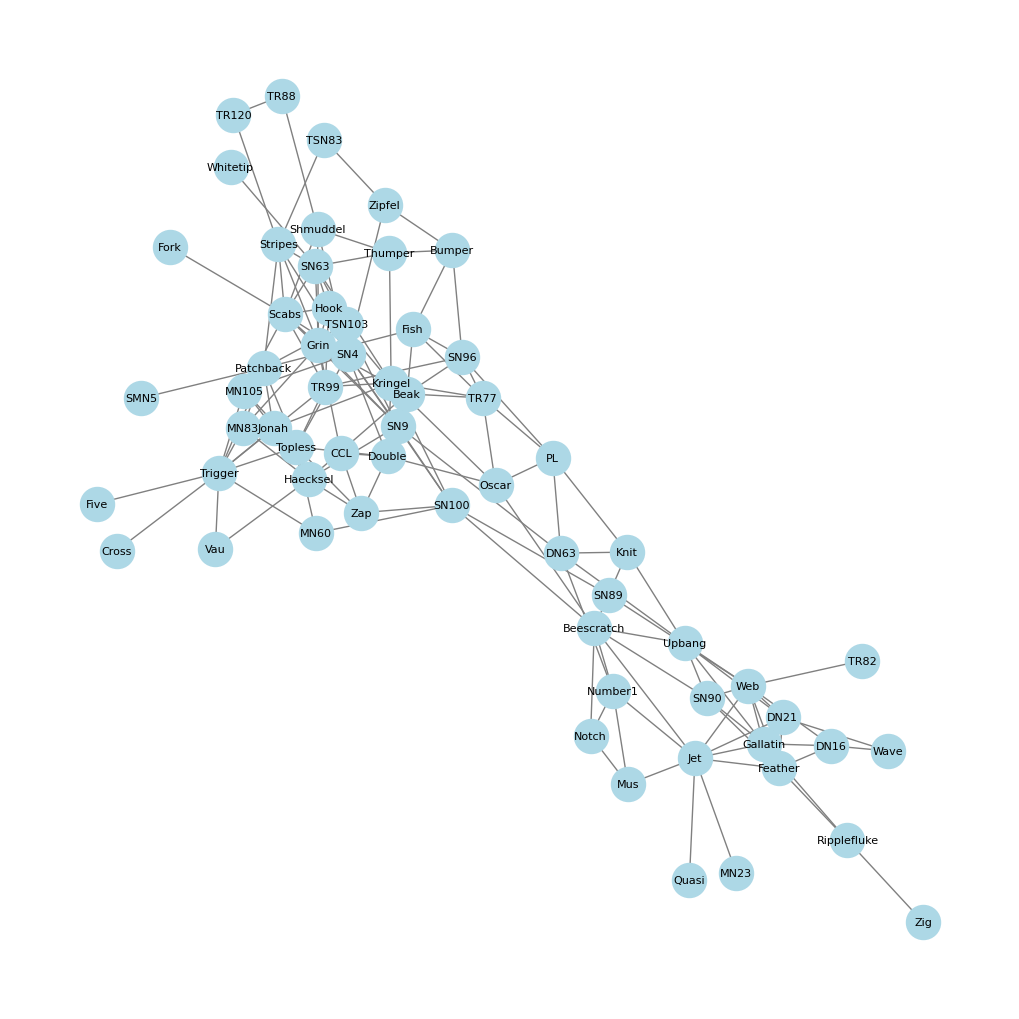

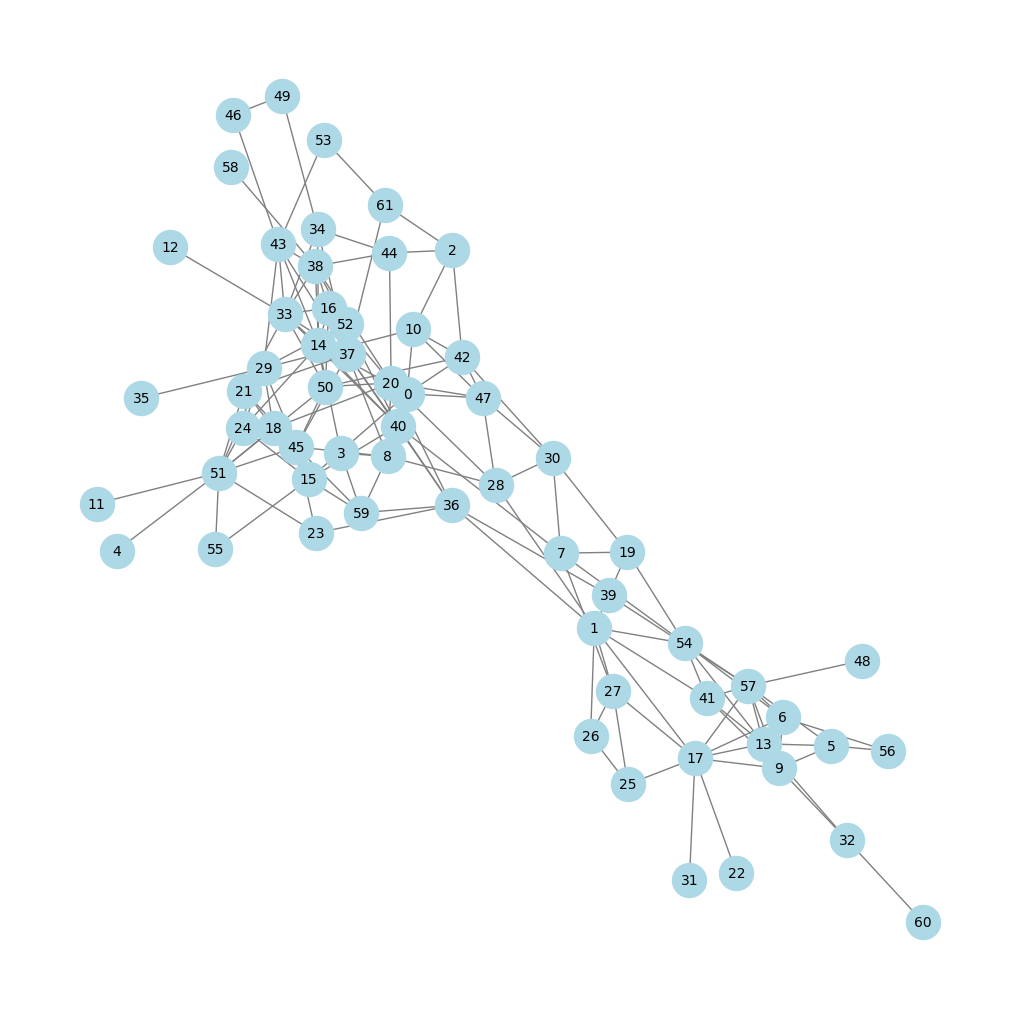

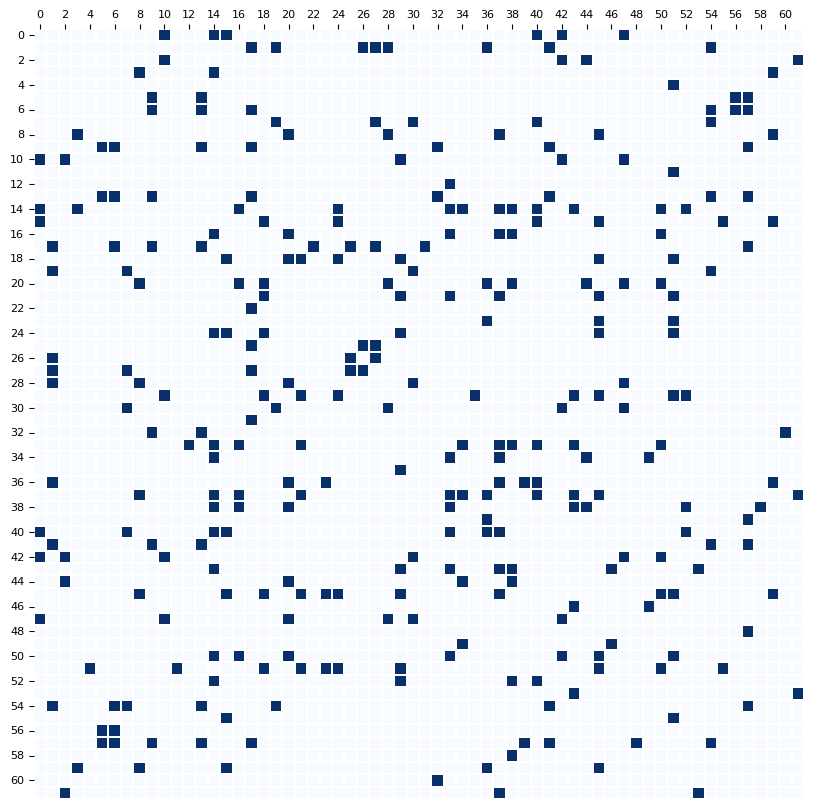

In [5]:
G = nx.read_gml("C://Users//carlo//OneDrive//Documents//Latentspacemodels_Networks//Complement//Examples//Dolphins//network_clean.gml")

pos = nx.spring_layout(G, seed=80)
plt.figure(figsize=(10,10))
nx.draw(G, pos=pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=600, font_size=8)
plt.show()

node_mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, node_mapping)
pos_relabel = {node_mapping[k]: v for k, v in pos.items()}
plt.figure(figsize=(10,10))
nx.draw(G, pos=pos_relabel, with_labels=True, node_color="lightblue", edge_color="gray", node_size=600, font_size=10)
plt.show()
inverse_mapping = {v: k for k, v in node_mapping.items()}

Y = nx.to_numpy_array(G, dtype=int)
Y = (Y > 0).astype(int)
n = Y.shape[0]
plt.figure(figsize=(10,10))

sns.heatmap(Y, annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.3, linecolor="white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top()
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=8)
plt.show()

In [6]:
seed_MAP = 42
diam = 10.0
n = Y.shape[0]
lr_MAP = 1e-2
n_starts_MAP = 1
n_iter_MAP = 25000
n_sim_iv = 2500
n_iter_cv = 1000
n_folds_cv = 5

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

#### Without weights

Multi_start (1)


MAP:  32%|███▏      | 8003/25000 [00:55<01:58, 143.70it/s, logpost=-434.5089, loglik=-433.8613, logprior=-0.6476, ||grad||=0.0140, patience=100]


[STOP] Early stopping at iter 8002 (no improvement in 101 steps)

Best log-posterior: -434.5089


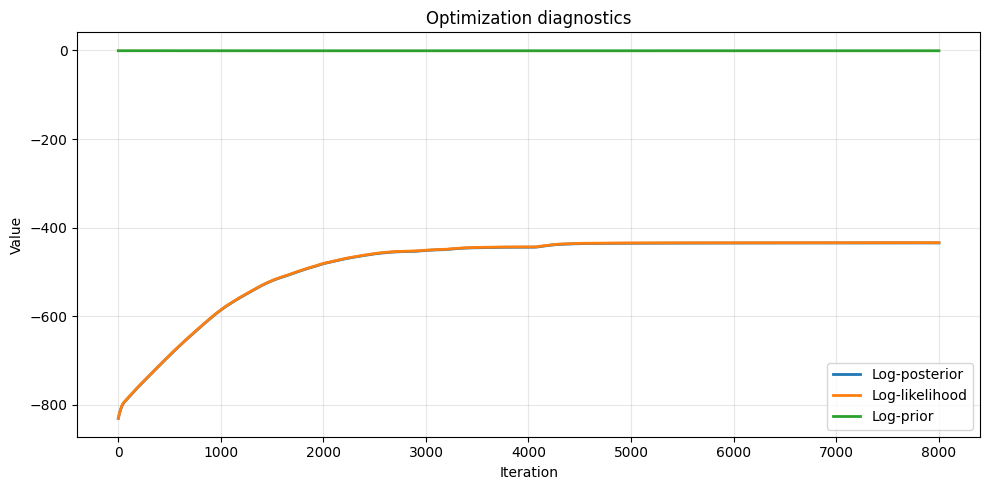

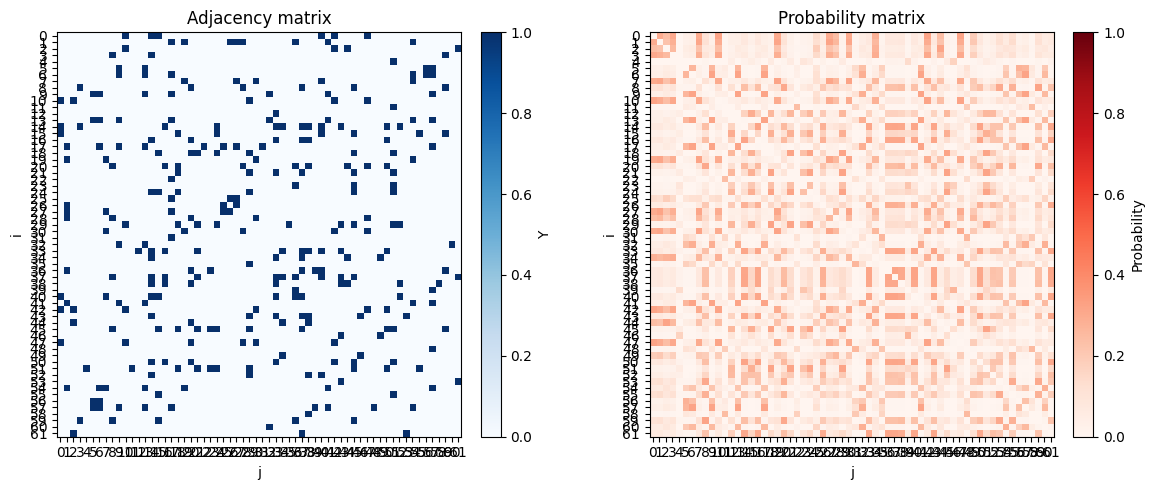

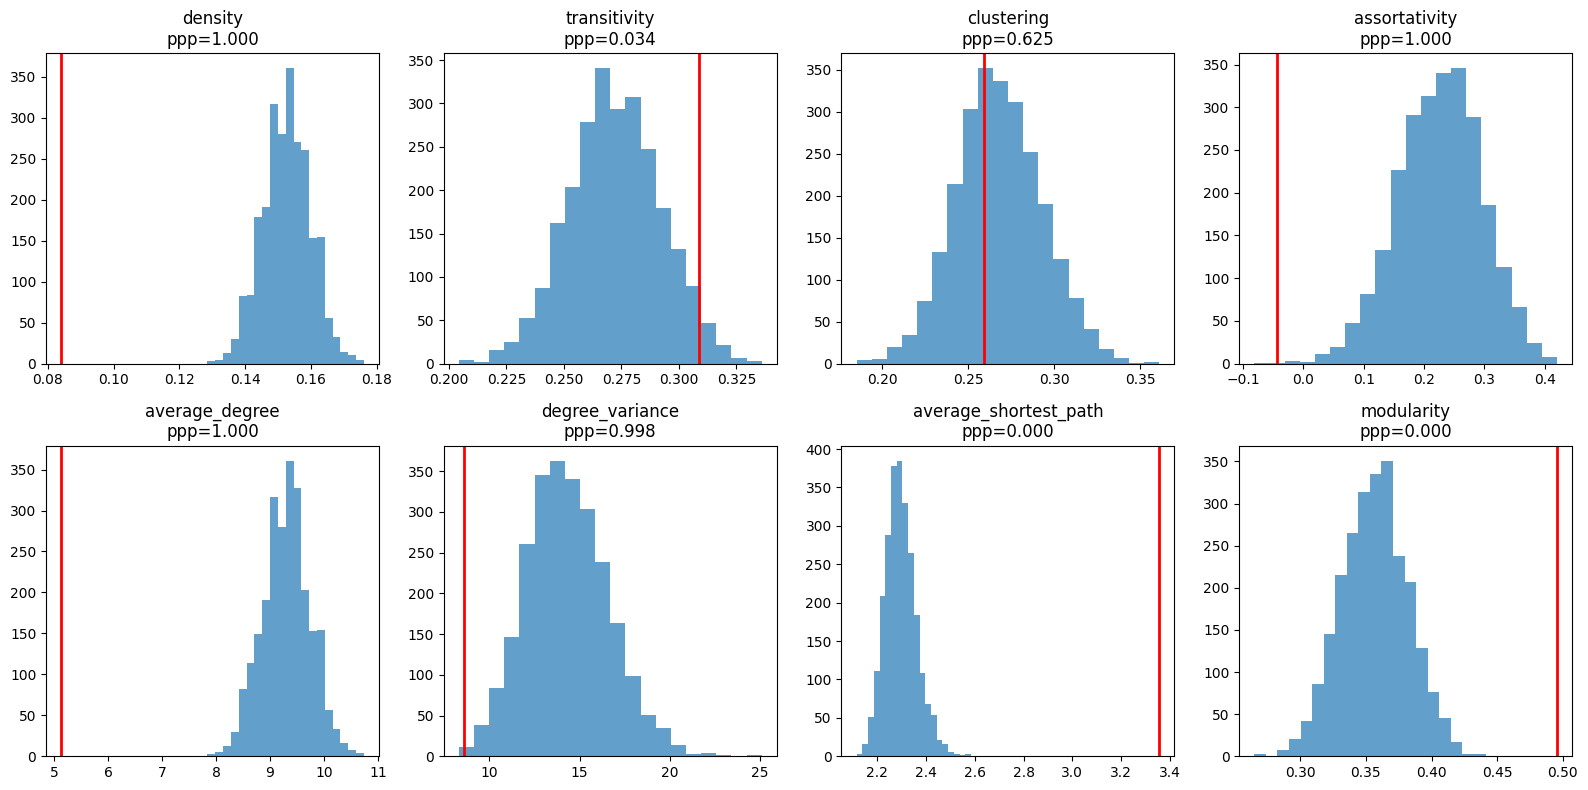

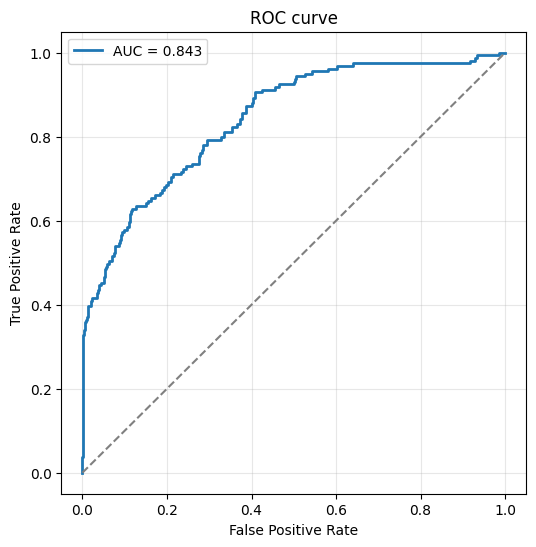

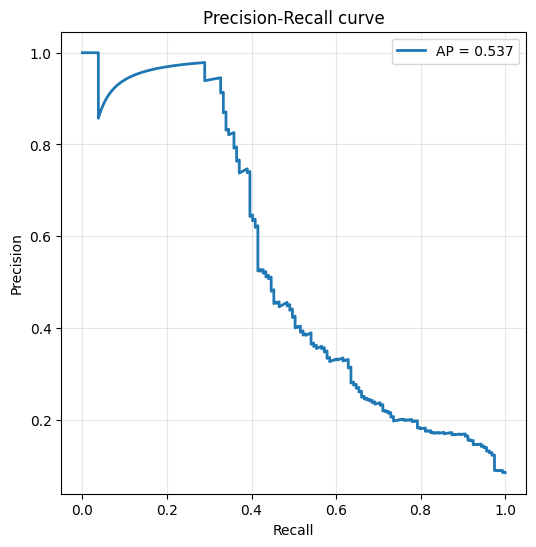

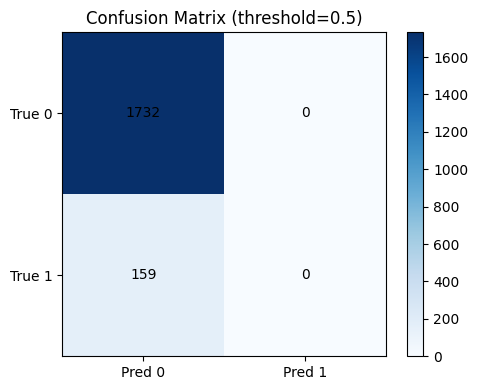

MAP: 100%|██████████| 1000/1000 [00:09<00:00, 110.13it/s, logpost=-317.0521, loglik=-316.4128, logprior=-0.6393, ||grad||=0.0140, patience=0]


{'mean_auc': 0.7861330145603469, 'std_auc': 0.020743506524148445, 'min_auc': np.float64(0.7675358643100578), 'max_auc': np.float64(0.8133496631965706), 'n_folds': 5}


In [7]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_R1_c.pkl")

#### With weights

Multi_start (1)


MAP:   7%|▋         | 1677/25000 [00:10<02:24, 161.43it/s, logpost=-404.7526, loglik=-404.7526, logprior=0.0000, ||grad||=0.0046, patience=100]


[STOP] Early stopping at iter 1676 (no improvement in 101 steps)

Best log-posterior: -404.7526


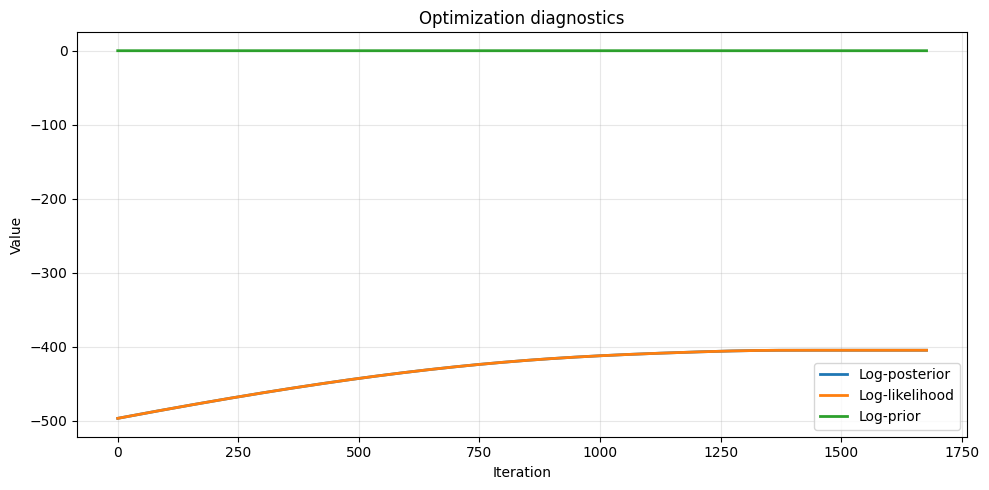

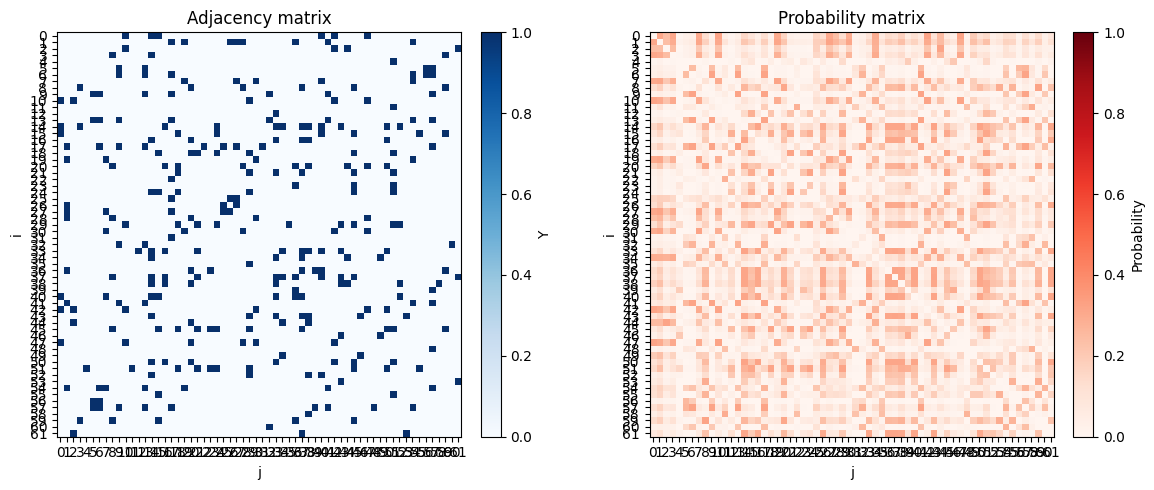

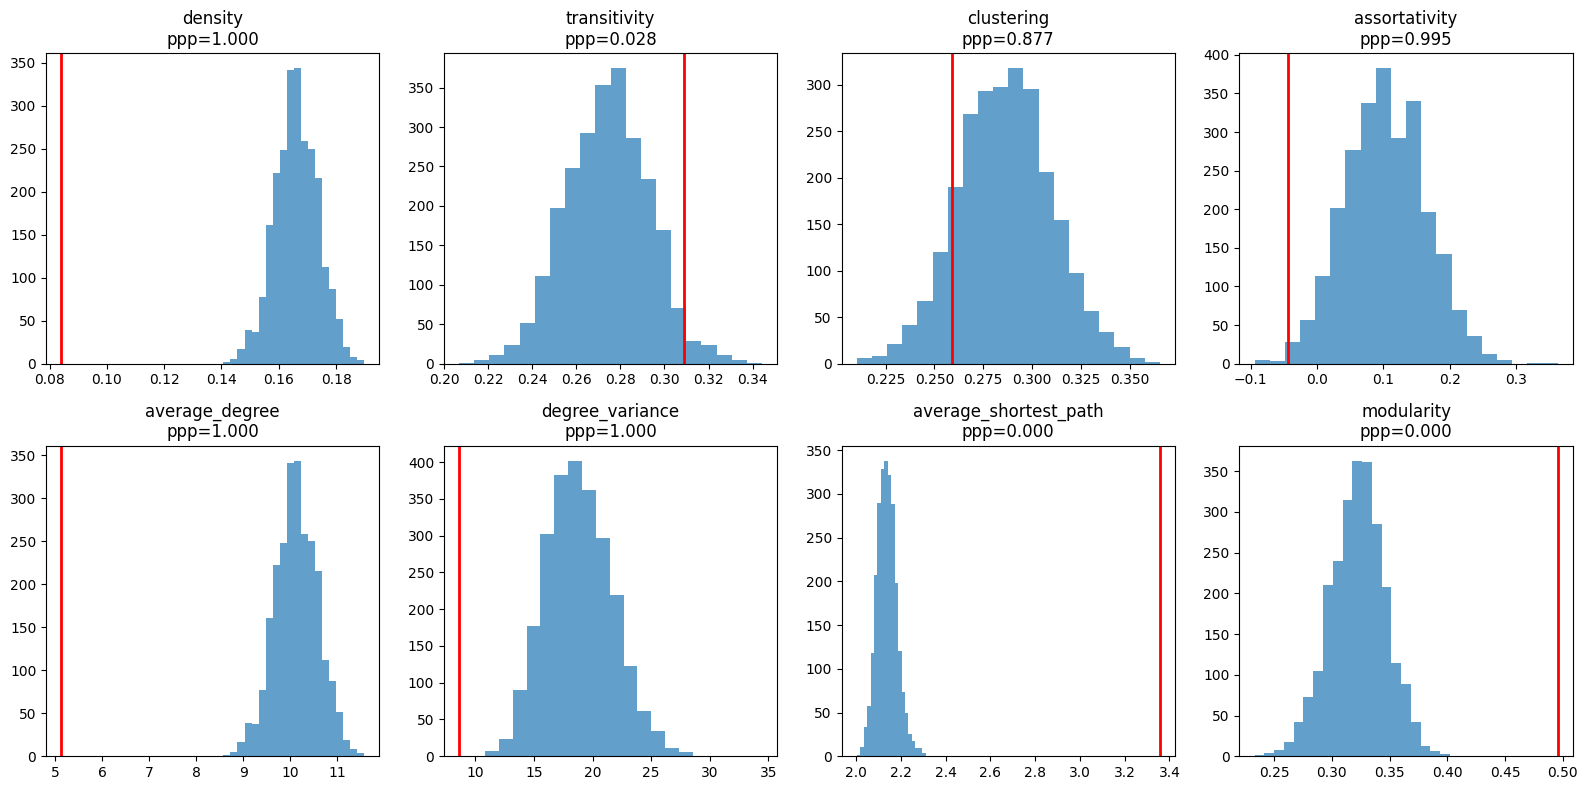

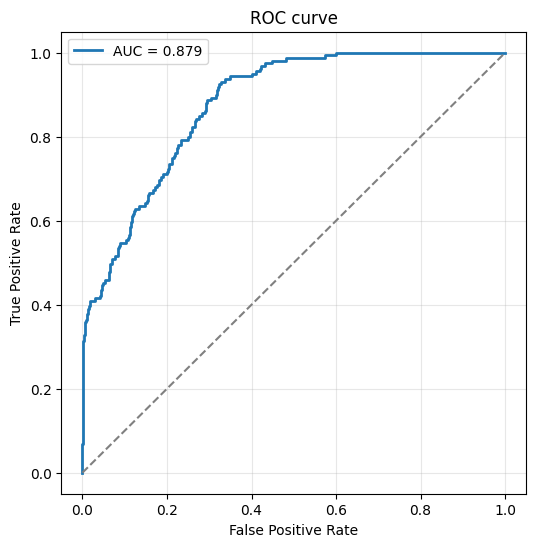

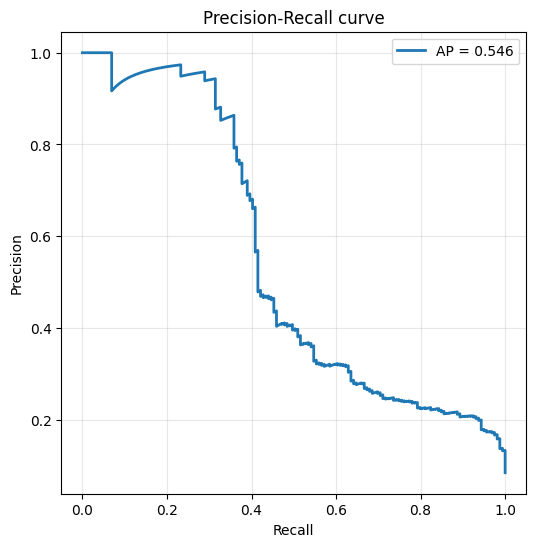

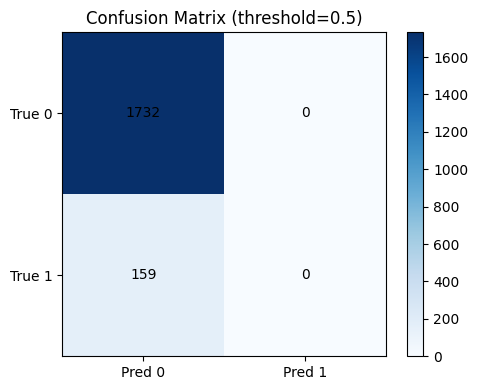

MAP: 100%|██████████| 1000/1000 [00:05<00:00, 191.06it/s, logpost=-305.9161, loglik=-305.9161, logprior=0.0000, ||grad||=0.0098, patience=3]


{'mean_auc': 0.8229035938779731, 'std_auc': 0.02849007543475371, 'min_auc': np.float64(0.7711817389236745), 'max_auc': np.float64(0.8487179487179487), 'n_folds': 5}


In [8]:
geometry = EuclideanGeometry(d=1, D=diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_R1_p.pkl")

### Model $\mathbb{R}^2$

#### Without weigths

Multi_start (1)


MAP: 100%|██████████| 25000/25000 [03:05<00:00, 134.62it/s, logpost=-310.3055, loglik=-309.6363, logprior=-0.6692, ||grad||=0.0140, patience=1] 



Best log-posterior: -310.3055


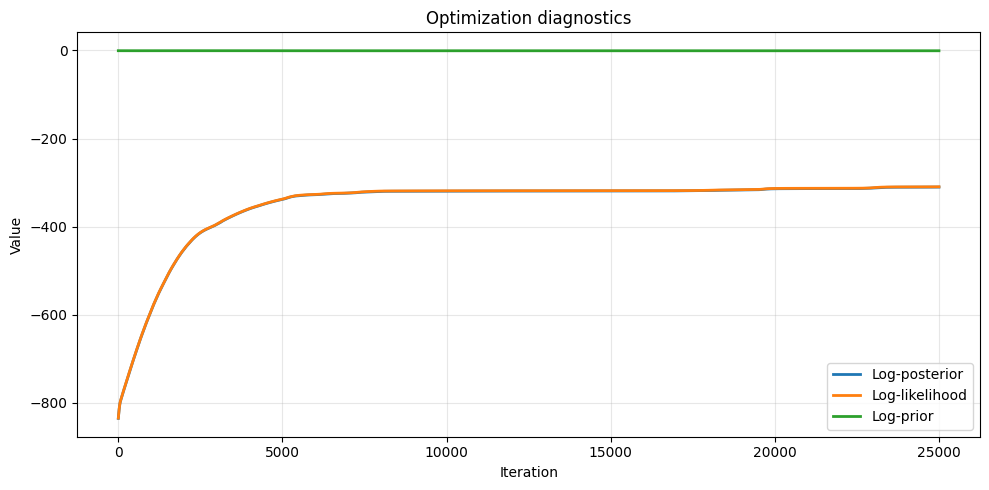

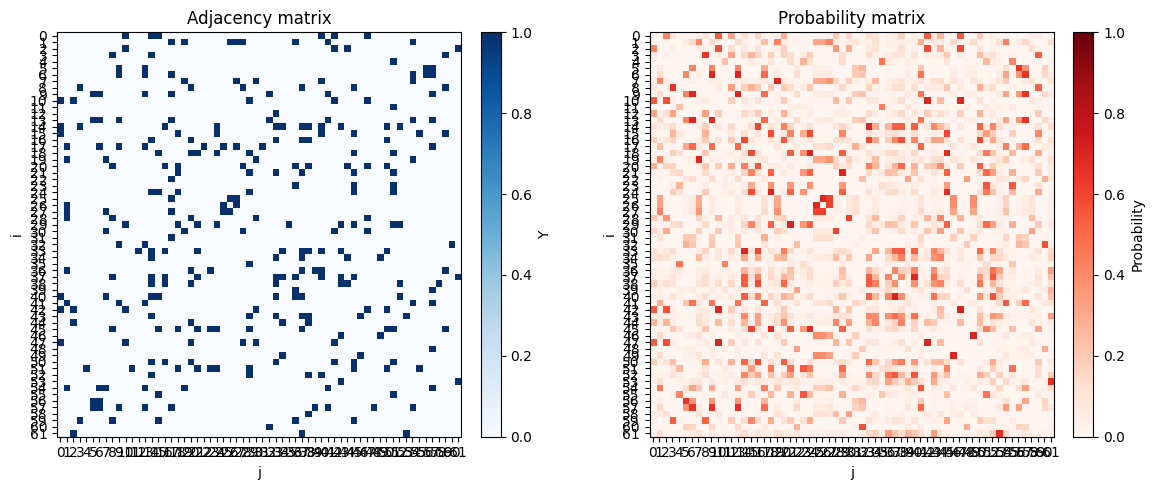

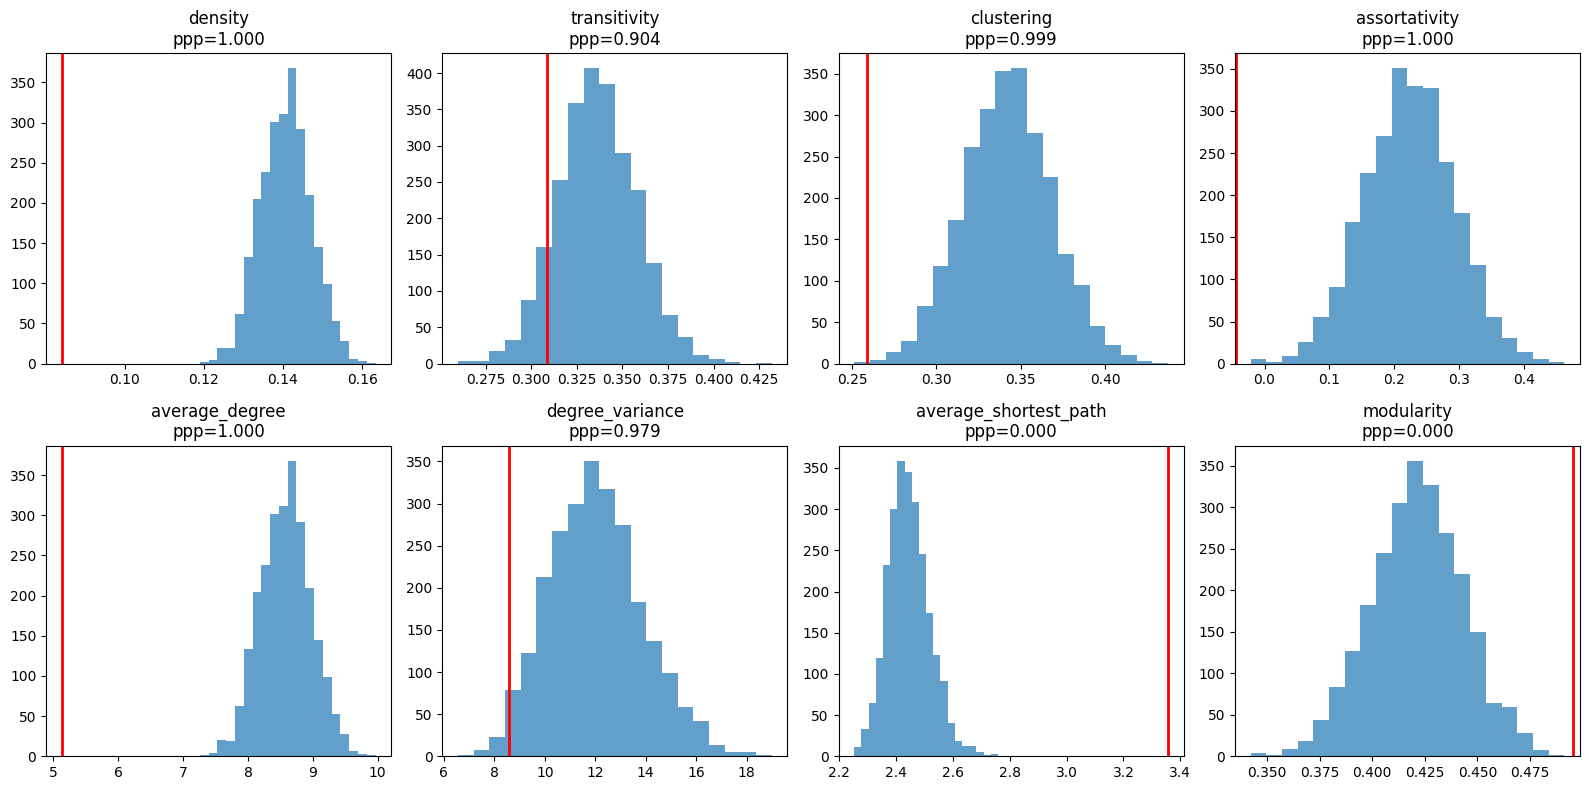

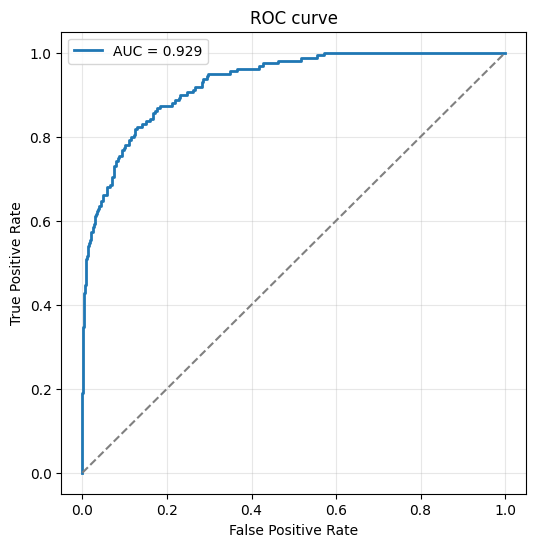

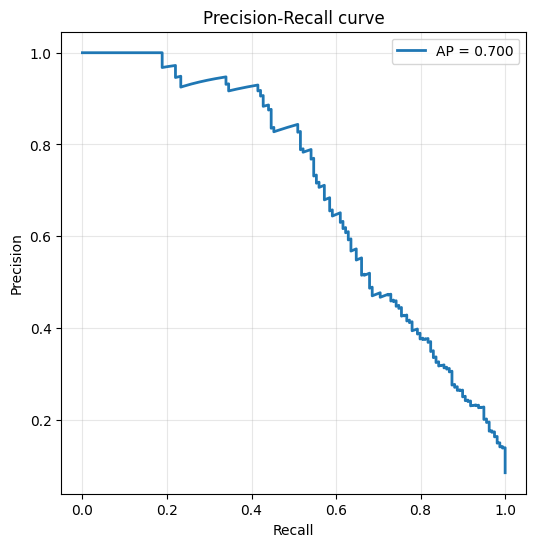

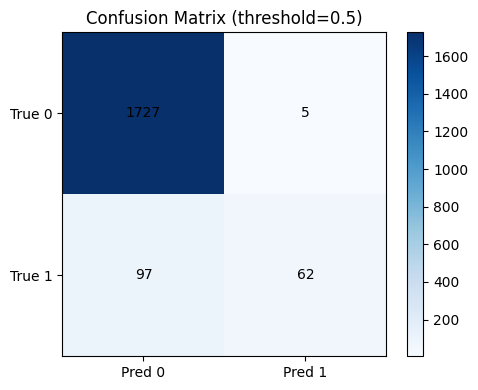

MAP: 100%|██████████| 1000/1000 [00:08<00:00, 124.86it/s, logpost=-219.6944, loglik=-219.0436, logprior=-0.6508, ||grad||=0.0140, patience=0]


{'mean_auc': 0.8618335435515853, 'std_auc': 0.030165297473084975, 'min_auc': np.float64(0.8261076325592455), 'max_auc': np.float64(0.9164727495407227), 'n_folds': 5}


In [9]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_R2_c.pkl")

#### With weights

Multi_start (1)


MAP:   6%|▌         | 1400/25000 [00:06<01:54, 206.39it/s, logpost=-291.7544, loglik=-291.7544, logprior=0.0000, ||grad||=0.0080, patience=100]


[STOP] Early stopping at iter 1399 (no improvement in 101 steps)

Best log-posterior: -291.7544


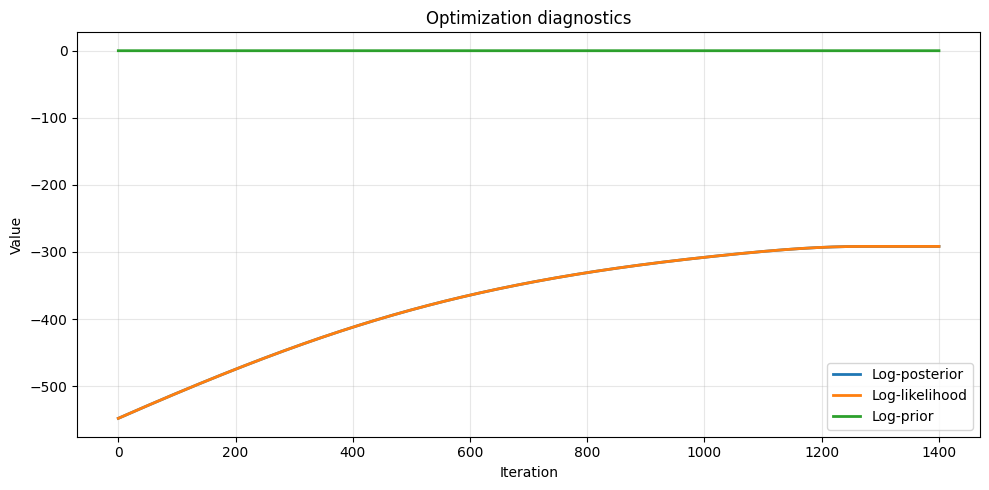

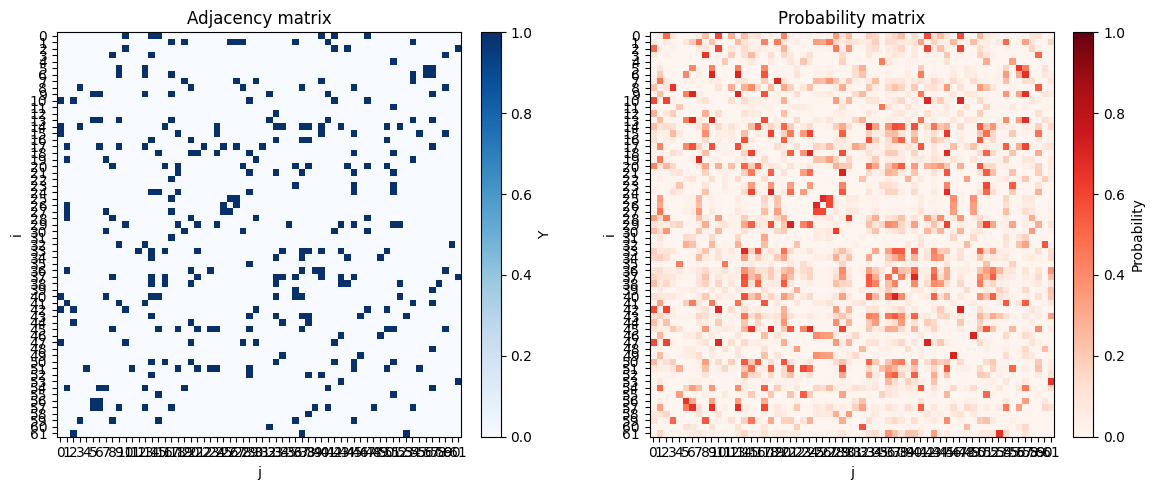

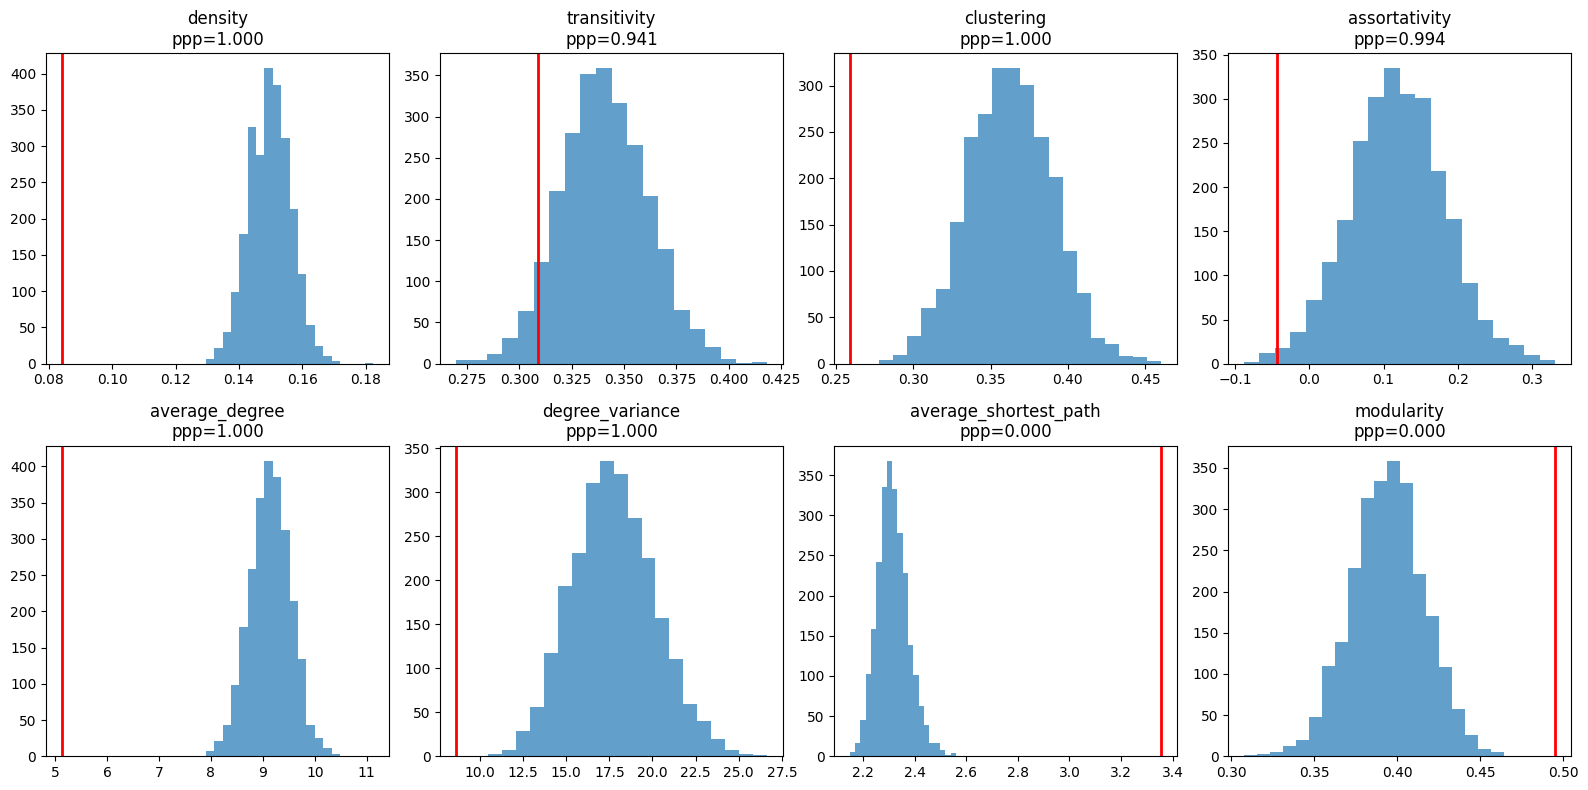

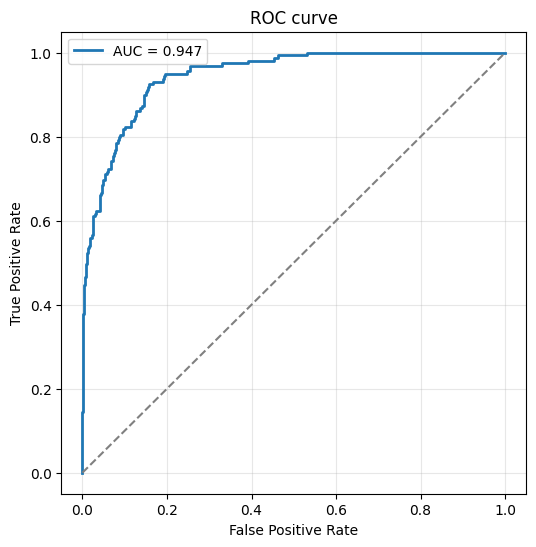

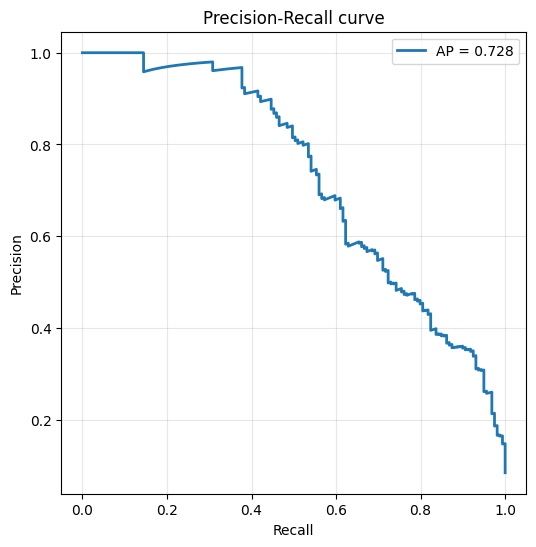

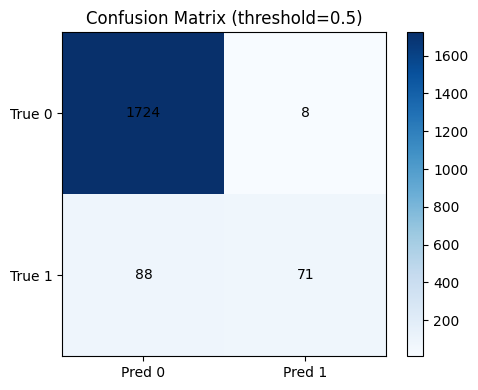

MAP:  24%|██▍       | 243/1000 [00:02<00:07, 107.69it/s, logpost=-213.6544, loglik=-213.6544, logprior=0.0000, ||grad||=0.0076, patience=49]


{'mean_auc': 0.9062137090933859, 'std_auc': 0.032101771602832625, 'min_auc': np.float64(0.8586827296504717), 'max_auc': np.float64(0.943661971830986), 'n_folds': 5}


In [10]:
geometry = EuclideanGeometry(d=2, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_R2_p.pkl")

### Model $\mathbb{R}^3$

#### Without weights

Multi_start (1)


MAP: 100%|██████████| 25000/25000 [02:59<00:00, 138.98it/s, logpost=-259.1842, loglik=-258.0809, logprior=-1.1033, ||grad||=0.0140, patience=0]



Best log-posterior: -259.1842


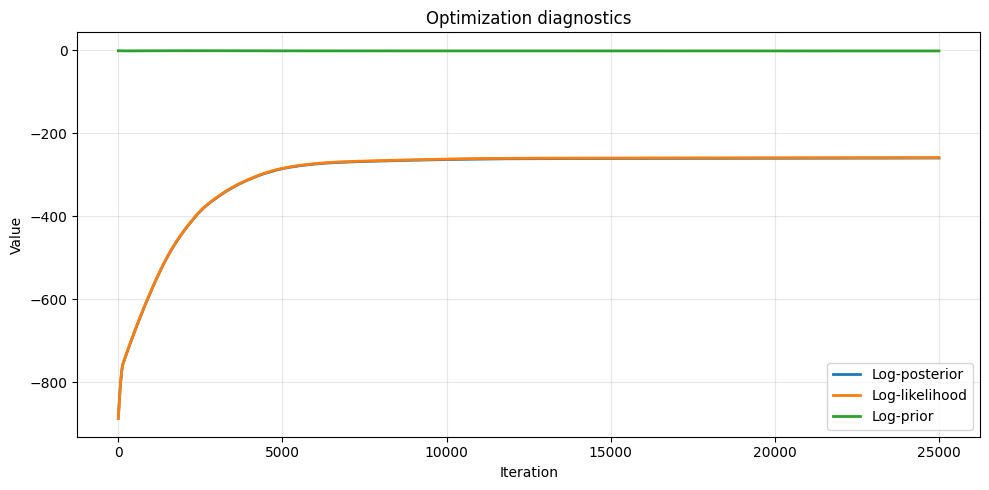

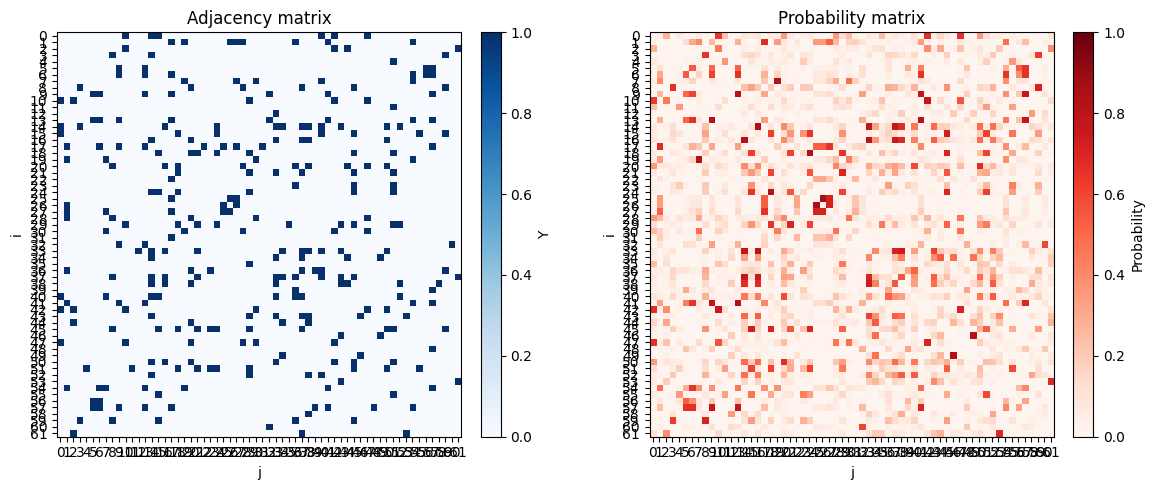

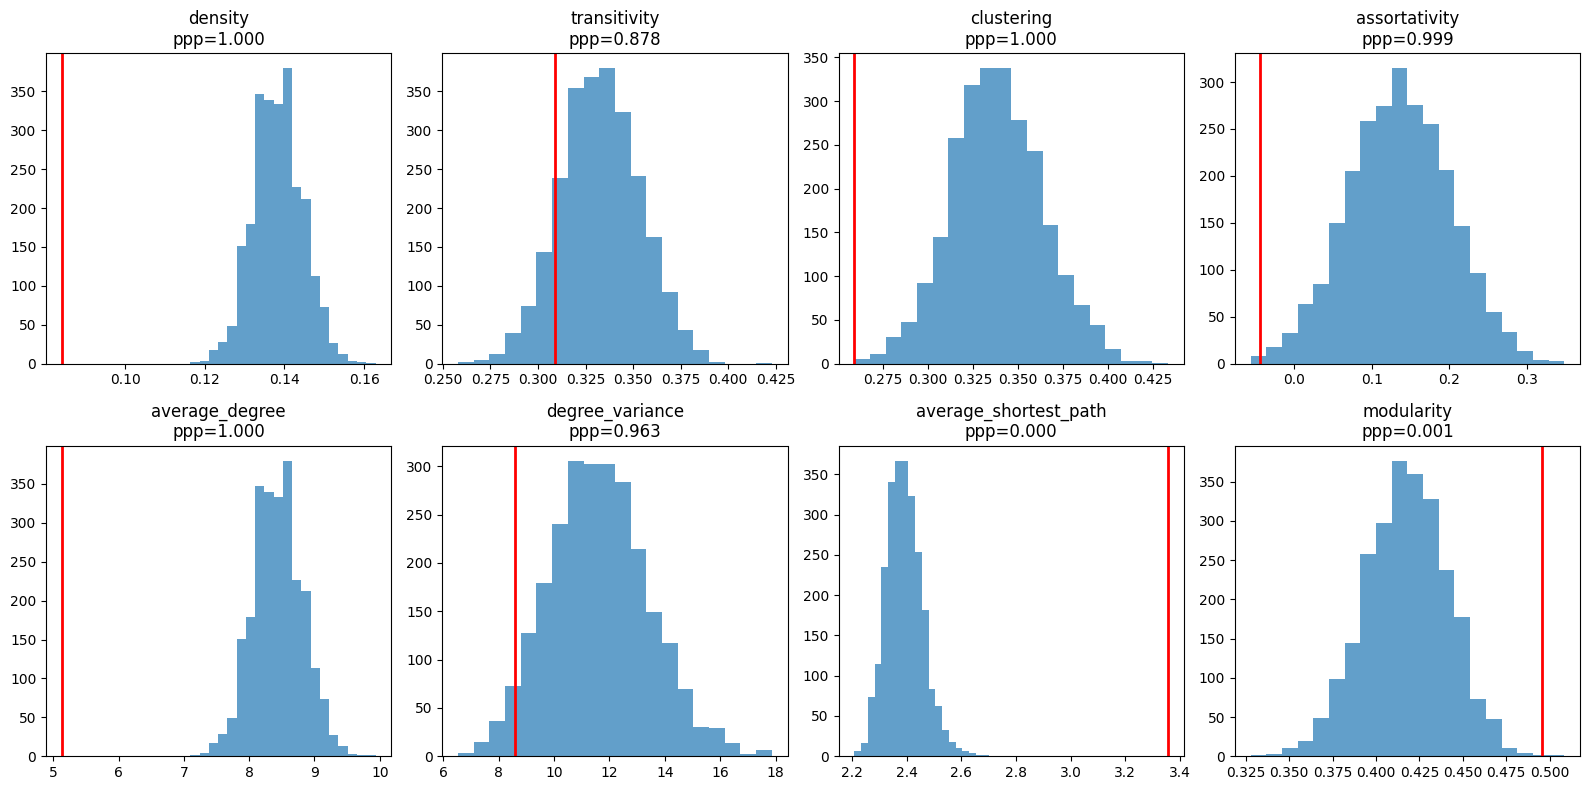

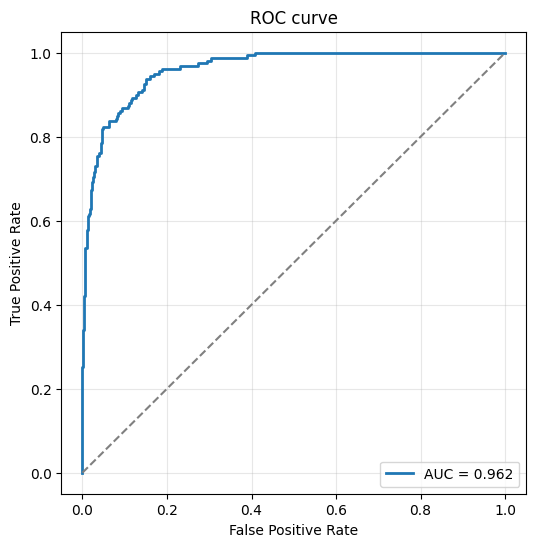

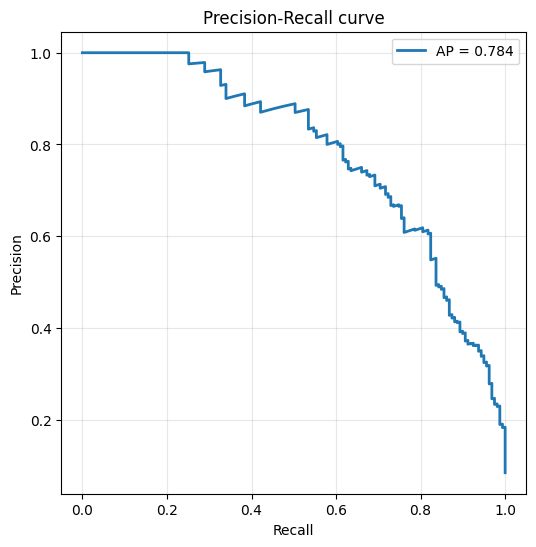

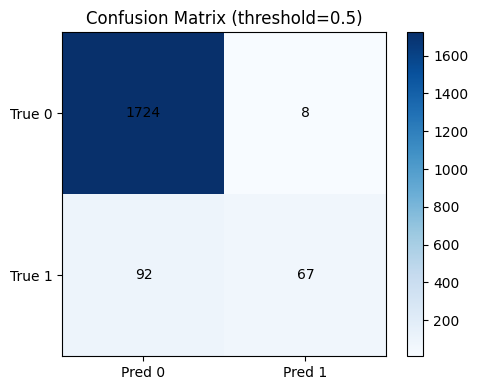

MAP: 100%|██████████| 1000/1000 [00:08<00:00, 120.50it/s, logpost=-182.4541, loglik=-181.4069, logprior=-1.0472, ||grad||=0.0139, patience=0]


{'mean_auc': 0.8973907081308784, 'std_auc': 0.027931153325601758, 'min_auc': np.float64(0.8635967345644766), 'max_auc': np.float64(0.9456215554194733), 'n_folds': 5}


In [11]:
geometry = EuclideanGeometry(d=3, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_R3_c.pkl")

#### With weights

Multi_start (1)


MAP:   6%|▌         | 1377/25000 [00:07<02:04, 190.10it/s, logpost=-244.5402, loglik=-244.5402, logprior=0.0000, ||grad||=0.0089, patience=100]


[STOP] Early stopping at iter 1376 (no improvement in 101 steps)

Best log-posterior: -244.5402


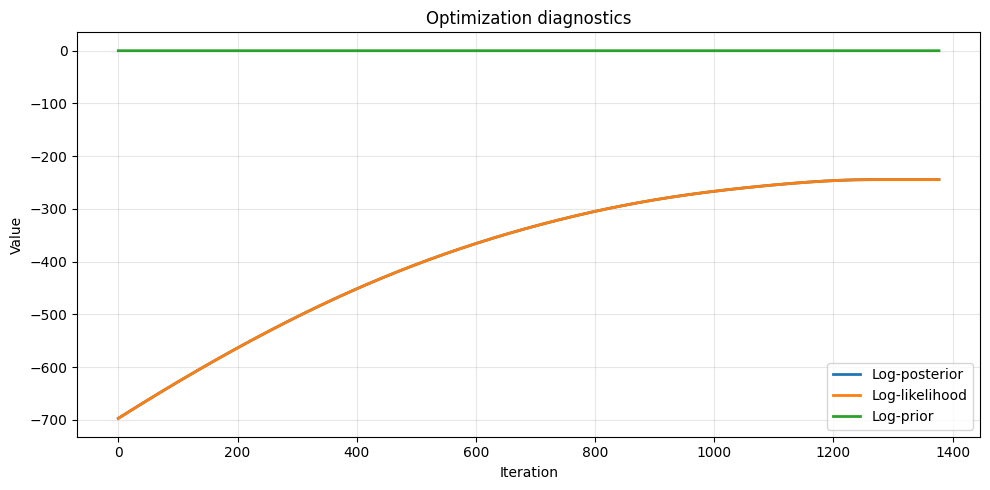

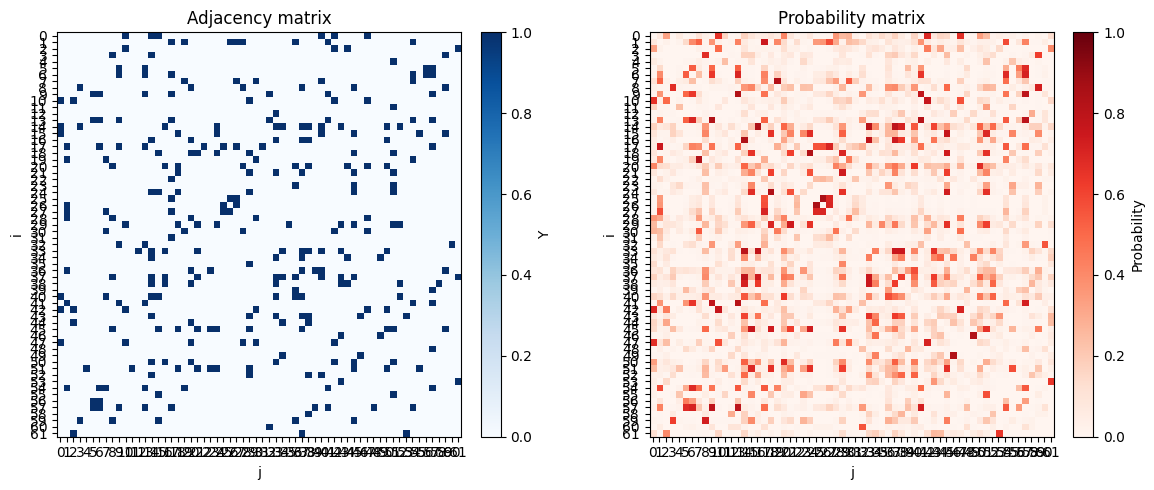

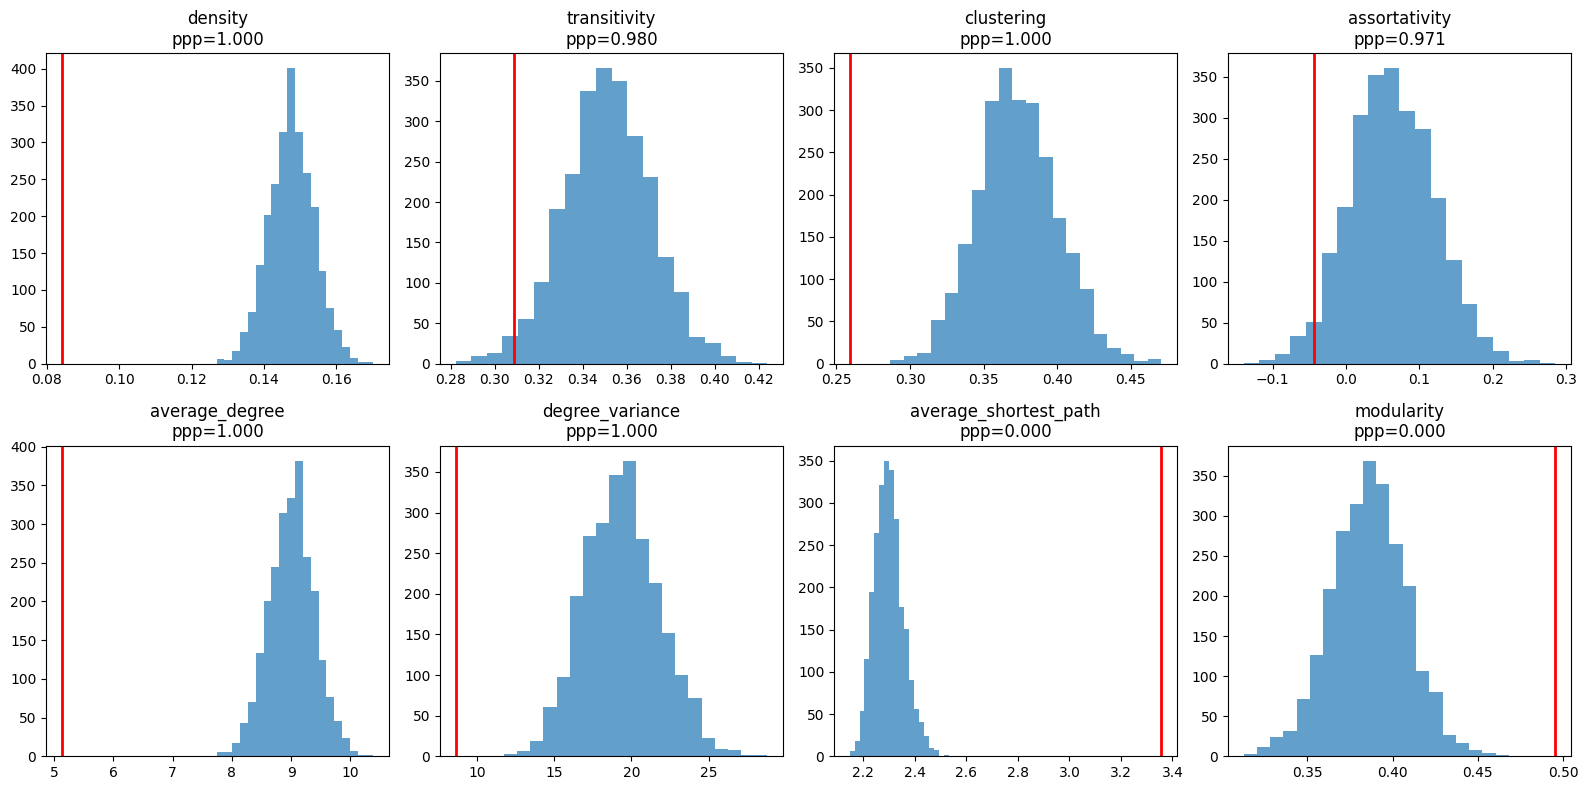

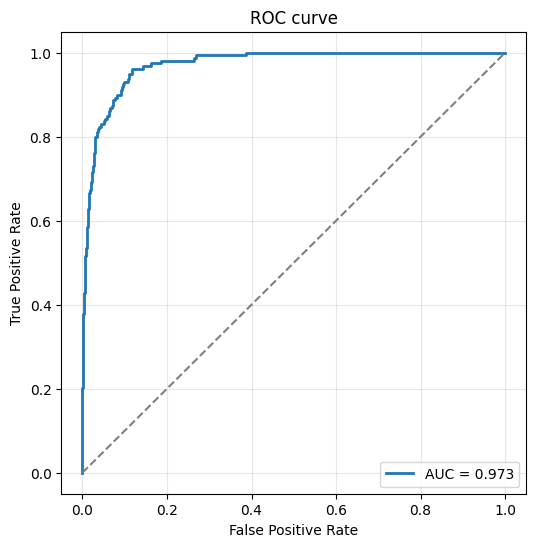

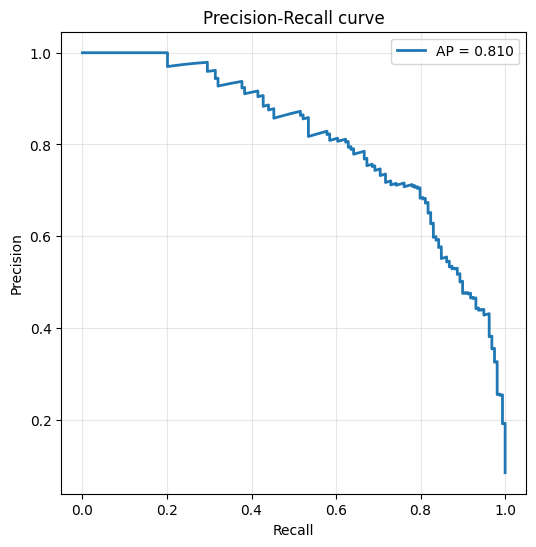

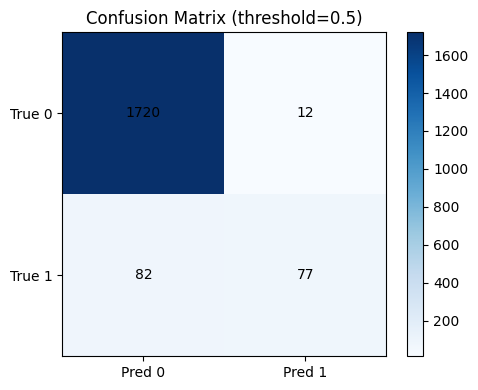

MAP:  16%|█▋        | 165/1000 [00:01<00:08, 93.80it/s, logpost=-183.3765, loglik=-183.3765, logprior=0.0000, ||grad||=0.0087, patience=49] 


{'mean_auc': 0.9504444108149581, 'std_auc': 0.02040307037275629, 'min_auc': np.float64(0.9304675716440423), 'max_auc': np.float64(0.9866503368034293), 'n_folds': 5}


In [12]:
geometry = EuclideanGeometry(d=3, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_R3_p.pkl")

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

#### Without weights

In [13]:
with open("Dolphins_R2_c.pkl", "rb") as f:
    results_R1_c = pickle.load(f)

Z_init = np.zeros((n,2))
Z_init[:,:] = np.asarray(results_R1_c['latent_params']['Z'])
for i in range(n):
    Z_init[i] = geometry.project_to_domain(Z_init[i])

Multi_start (1)


MAP:  21%|██▏       | 5315/25000 [00:43<02:39, 123.12it/s, logpost=-365.7078, loglik=-365.1575, logprior=-0.5502, ||grad||=0.0140, patience=100]


[STOP] Early stopping at iter 5314 (no improvement in 101 steps)

Best log-posterior: -365.7078


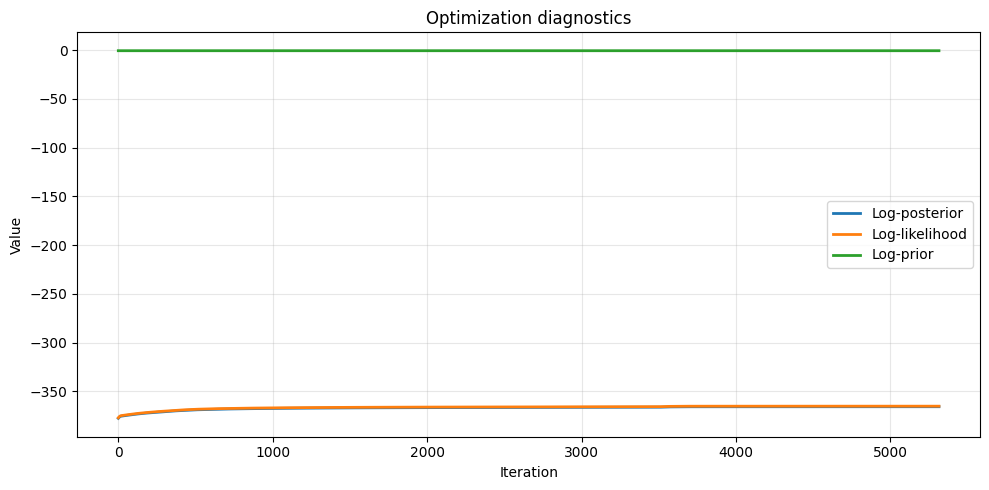

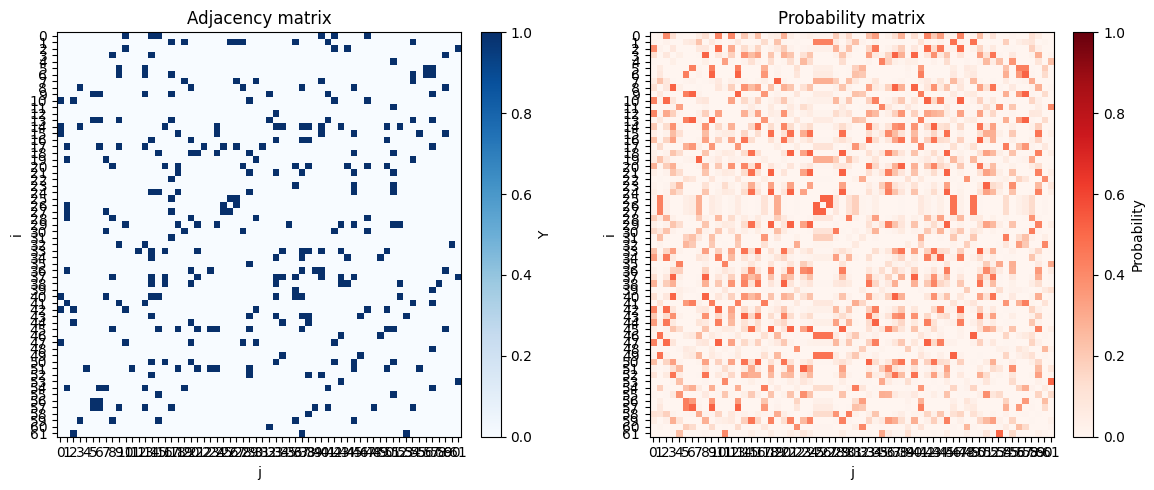

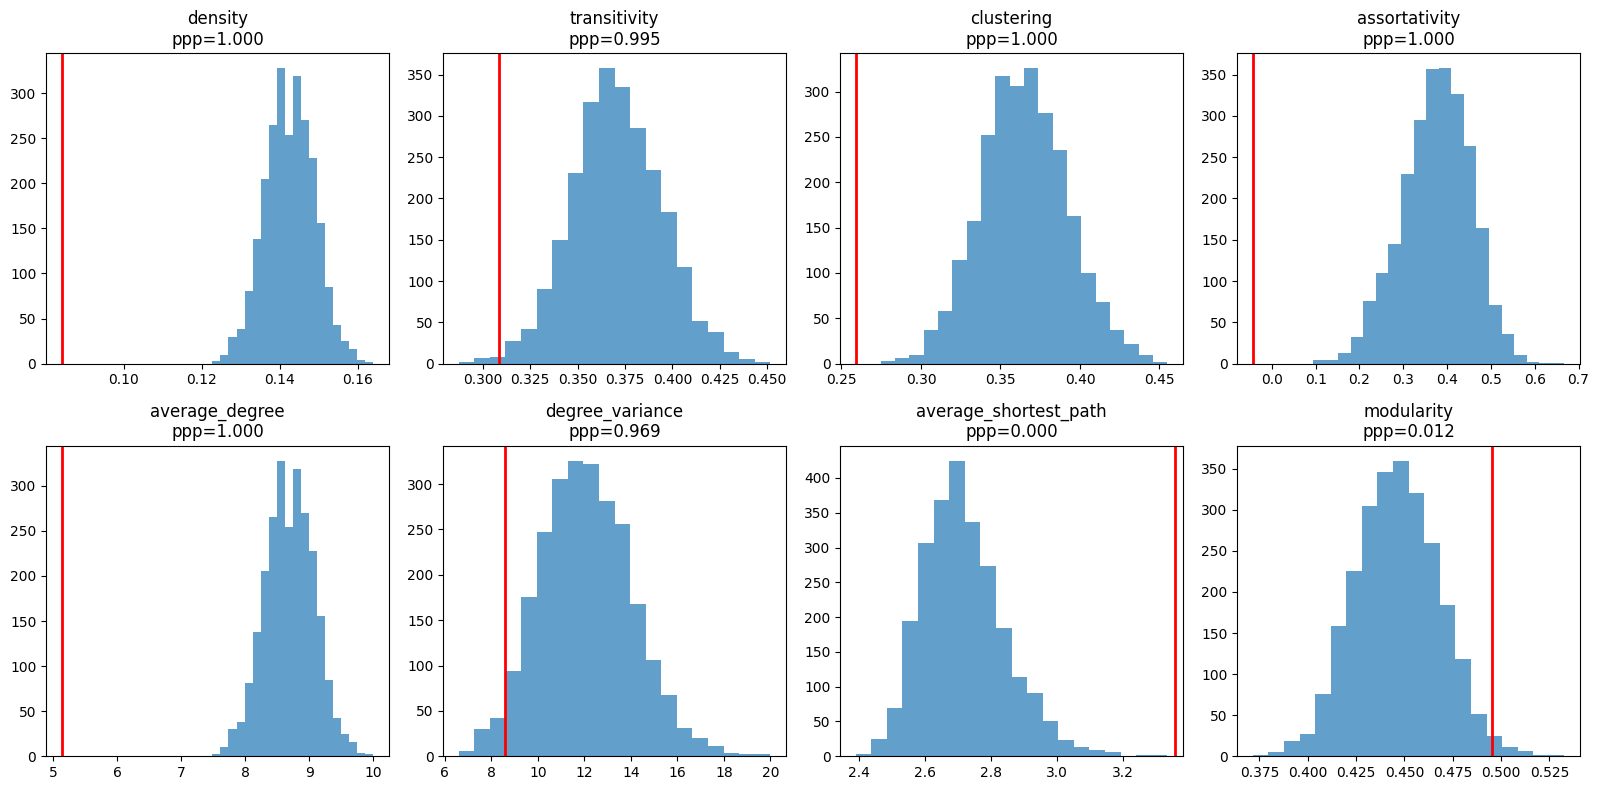

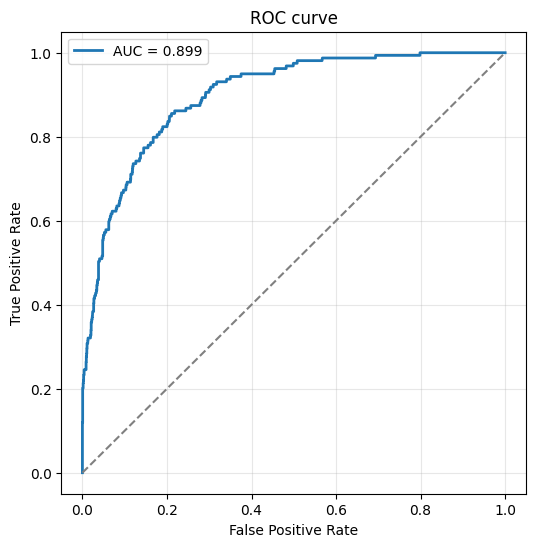

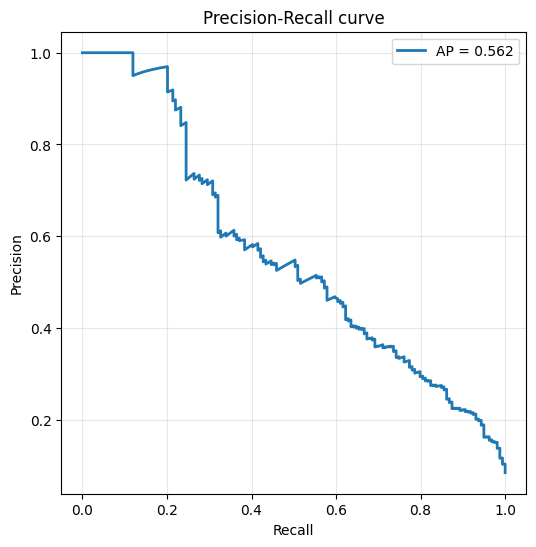

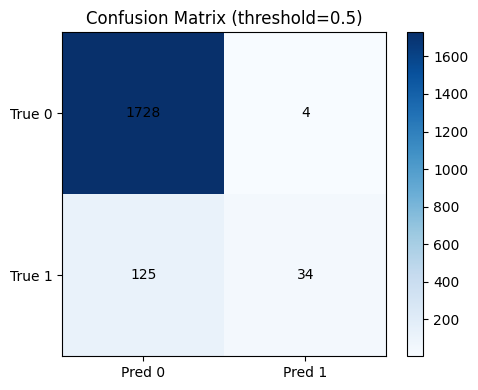

MAP: 100%|██████████| 1000/1000 [00:08<00:00, 118.88it/s, logpost=-262.7896, loglik=-262.2401, logprior=-0.5495, ||grad||=0.0139, patience=0]


{'mean_auc': 0.8683518482708422, 'std_auc': 0.04047373143992544, 'min_auc': np.float64(0.8037568360149006), 'max_auc': np.float64(0.9298224127372934), 'n_folds': 5}


In [14]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_S1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:   6%|▌         | 1404/25000 [00:06<01:49, 214.94it/s, logpost=-328.5676, loglik=-328.5676, logprior=0.0000, ||grad||=0.0069, patience=100]


[STOP] Early stopping at iter 1403 (no improvement in 101 steps)

Best log-posterior: -328.5676


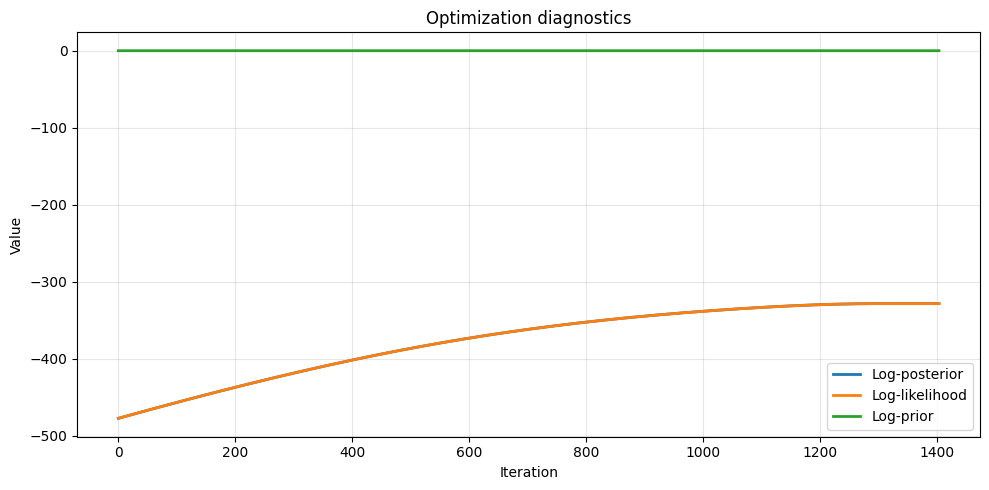

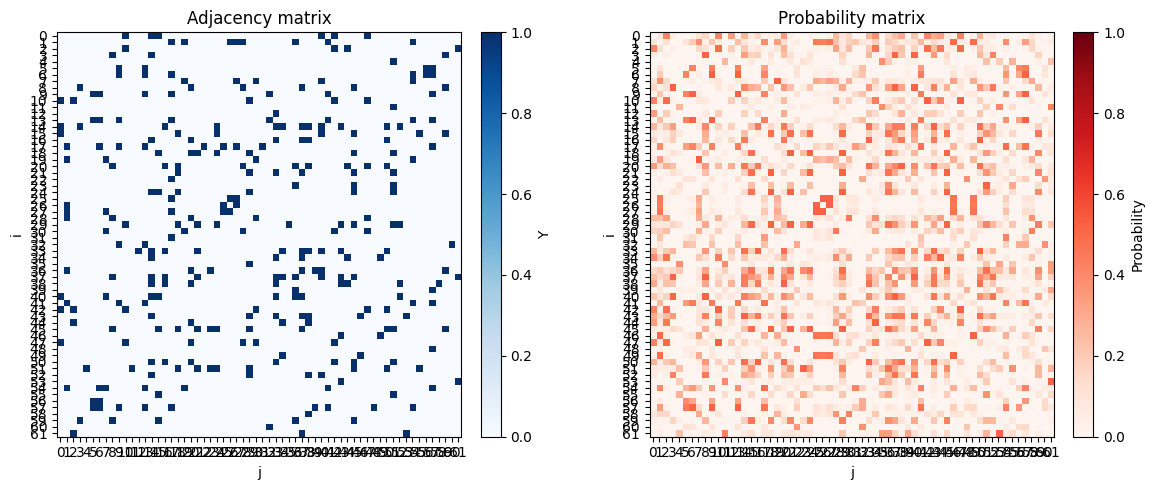

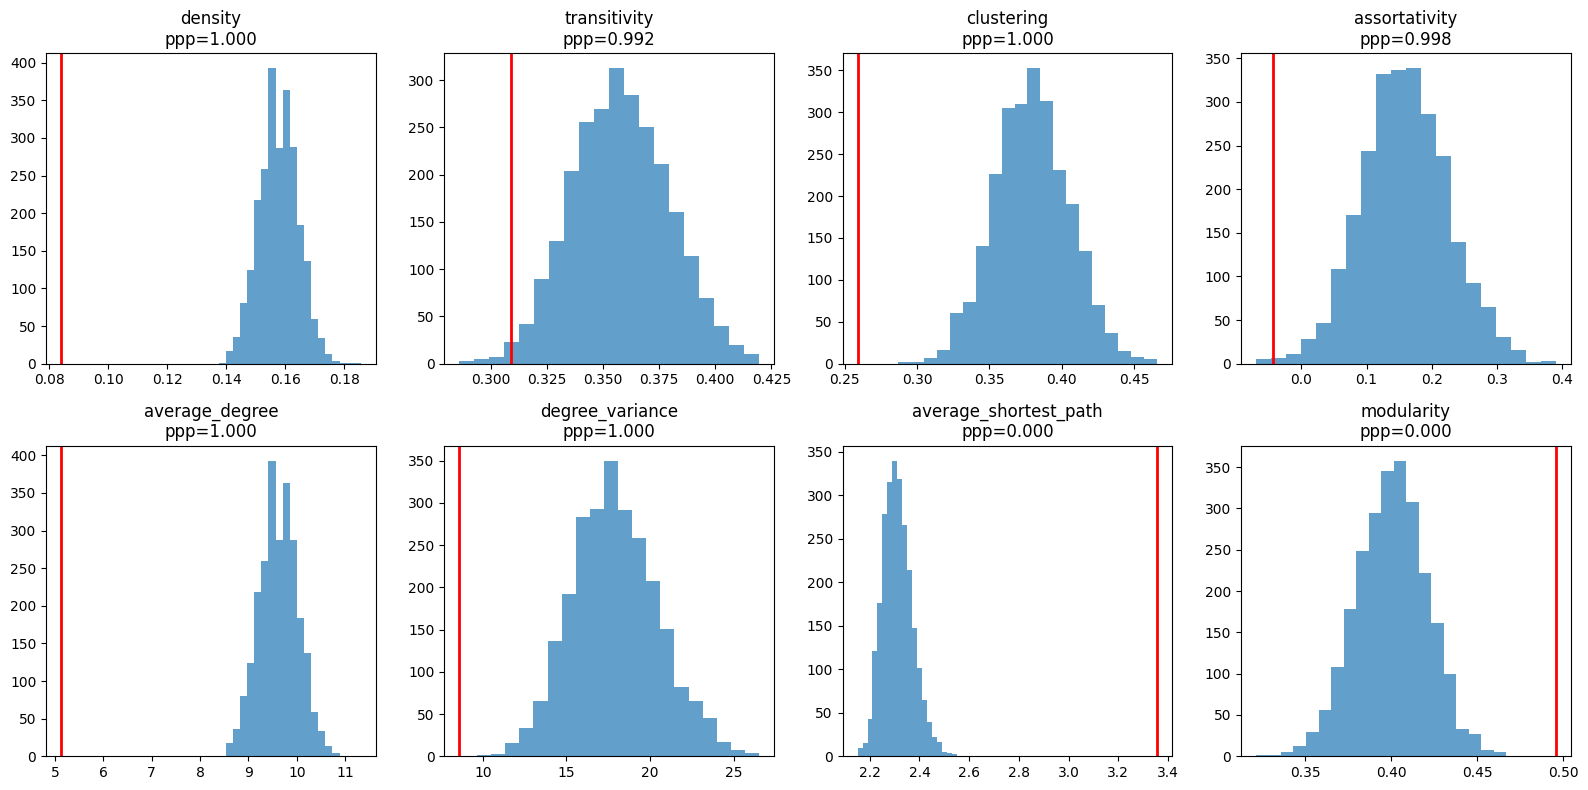

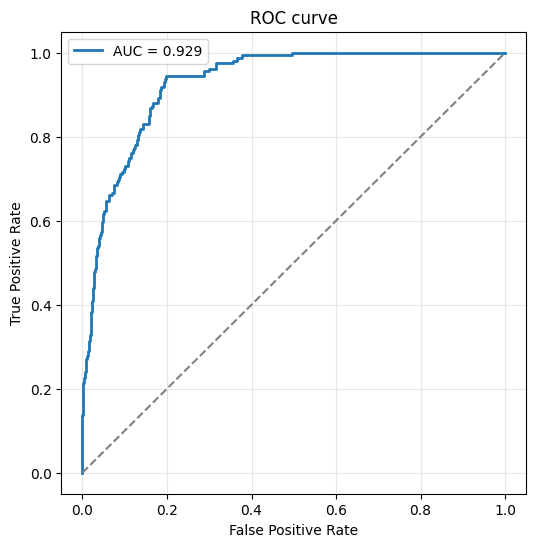

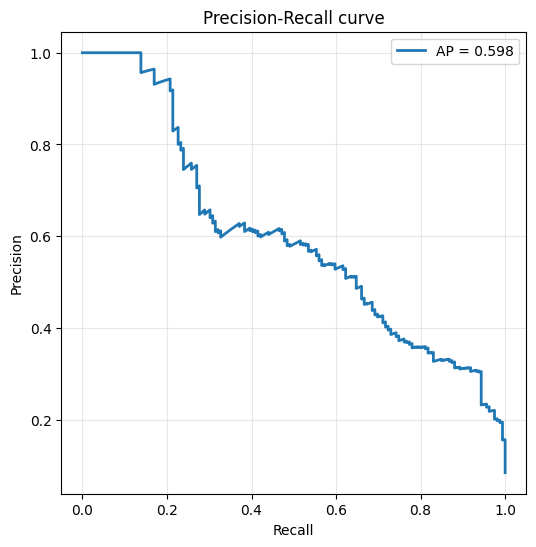

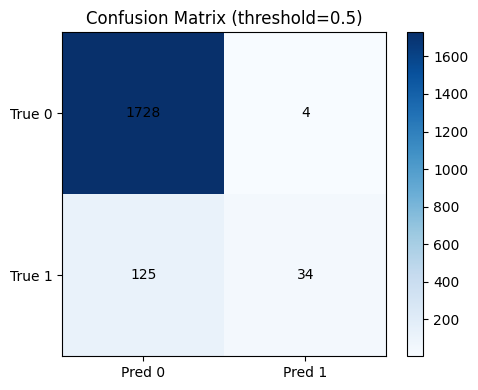

MAP:  31%|███       | 310/1000 [00:02<00:05, 120.64it/s, logpost=-246.9385, loglik=-246.9385, logprior=0.0000, ||grad||=0.0061, patience=49]


{'mean_auc': 0.8922748434010306, 'std_auc': 0.024734620412042534, 'min_auc': np.float64(0.8567805341998891), 'max_auc': np.float64(0.9315370483772198), 'n_folds': 5}


In [15]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_S1_p.pkl")

### Model $\mathbb{S}^2$

#### Without weights

In [16]:
with open("Dolphins_R3_p.pkl", "rb") as f:
    results_R3_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,:] = np.asarray(results_R3_p['latent_params']['Z'])

Multi_start (1)


MAP:  25%|██▍       | 6221/25000 [00:53<02:42, 115.24it/s, logpost=-293.1919, loglik=-292.4925, logprior=-0.6994, ||grad||=0.0137, patience=100]


[STOP] Early stopping at iter 6220 (no improvement in 101 steps)

Best log-posterior: -293.1919


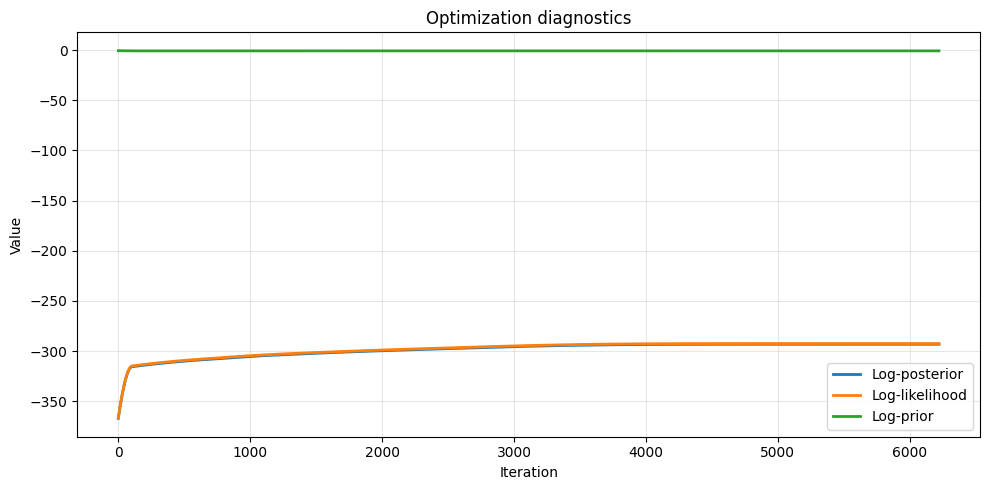

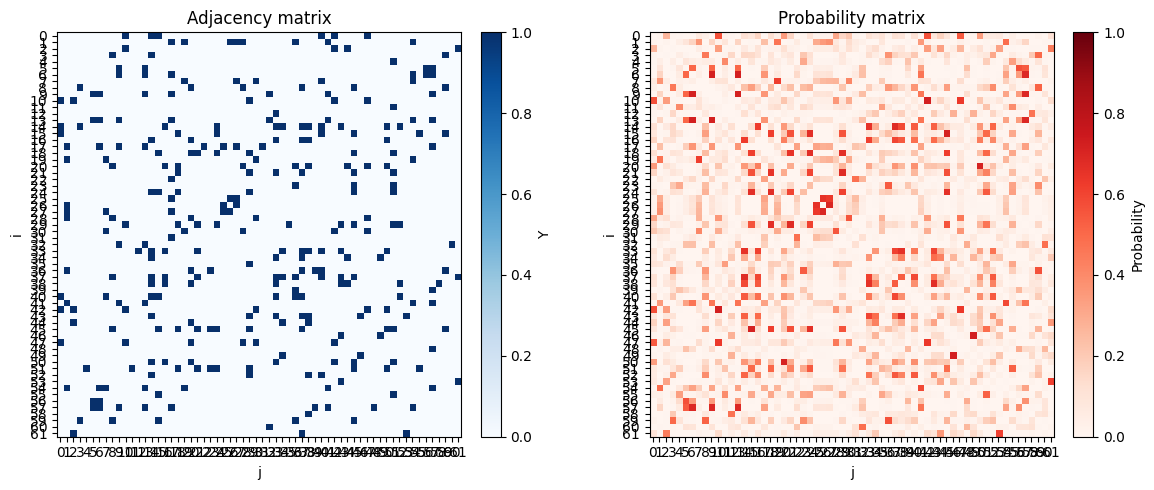

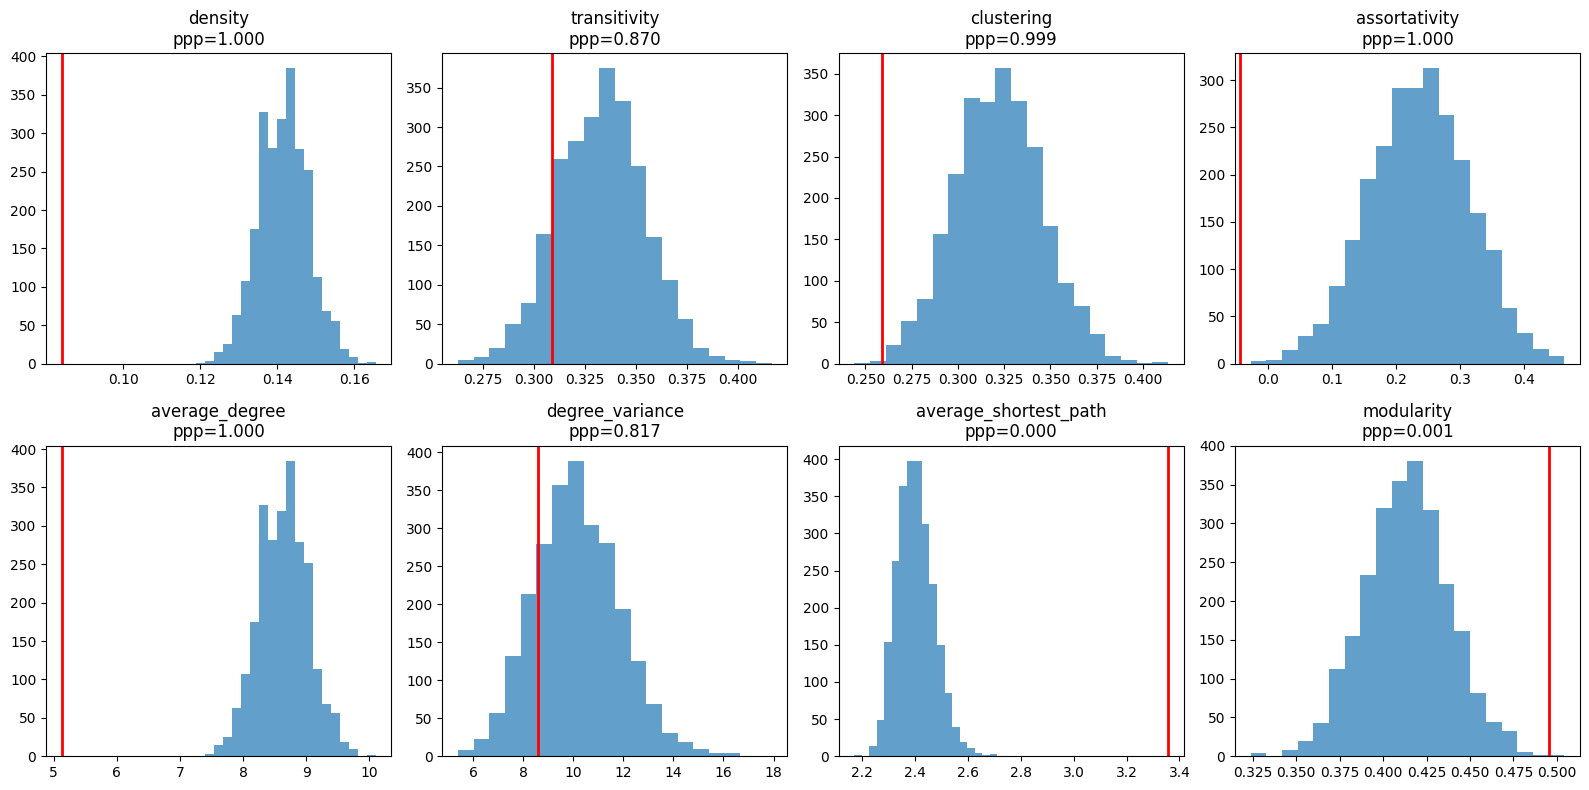

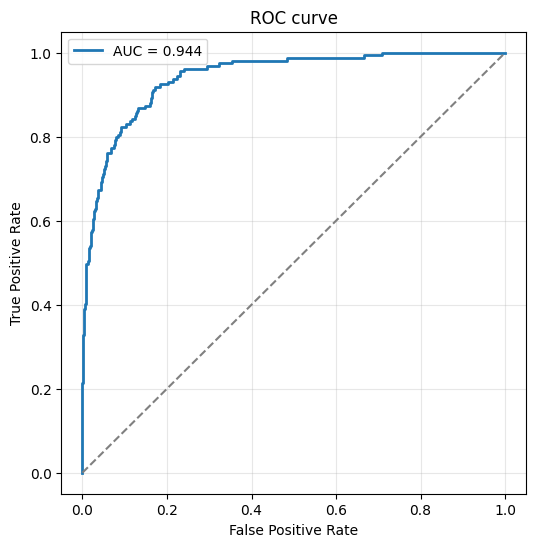

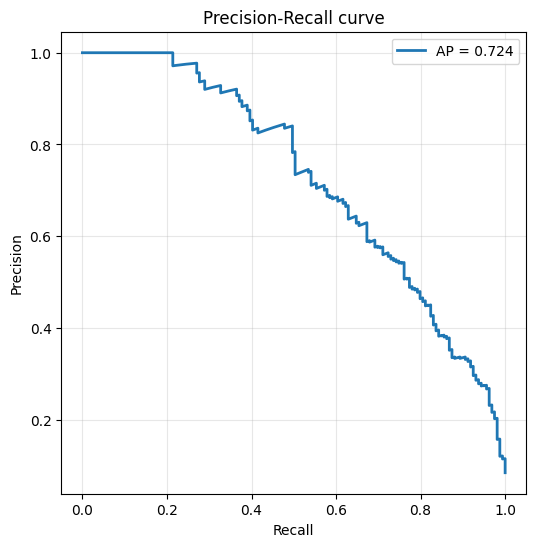

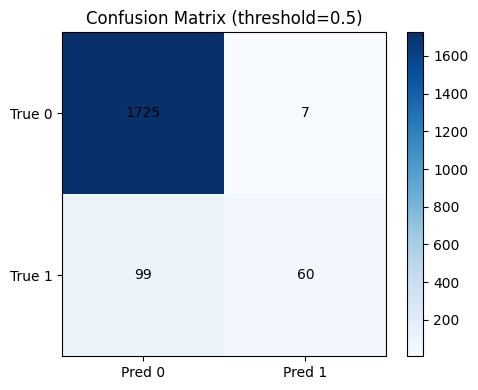

MAP: 100%|██████████| 1000/1000 [00:08<00:00, 117.02it/s, logpost=-207.2389, loglik=-206.5624, logprior=-0.6765, ||grad||=0.0139, patience=0]


{'mean_auc': 0.8965913904558092, 'std_auc': 0.03244736883140185, 'min_auc': np.float64(0.8423555520329714), 'max_auc': np.float64(0.9317819963257807), 'n_folds': 5}


In [17]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_S2_c.pkl")


alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:   5%|▌         | 1361/25000 [00:06<01:53, 208.00it/s, logpost=-270.7597, loglik=-270.7597, logprior=0.0000, ||grad||=0.0081, patience=100]


[STOP] Early stopping at iter 1360 (no improvement in 101 steps)

Best log-posterior: -270.7597


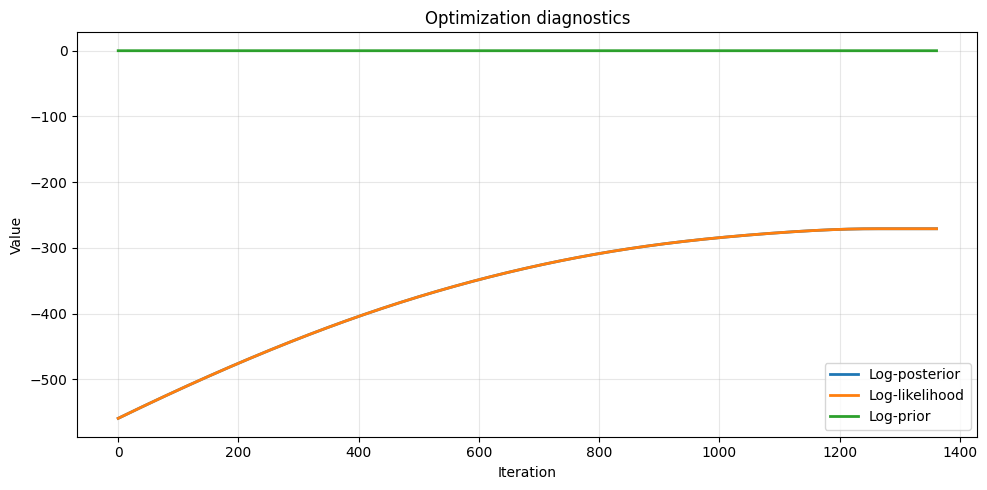

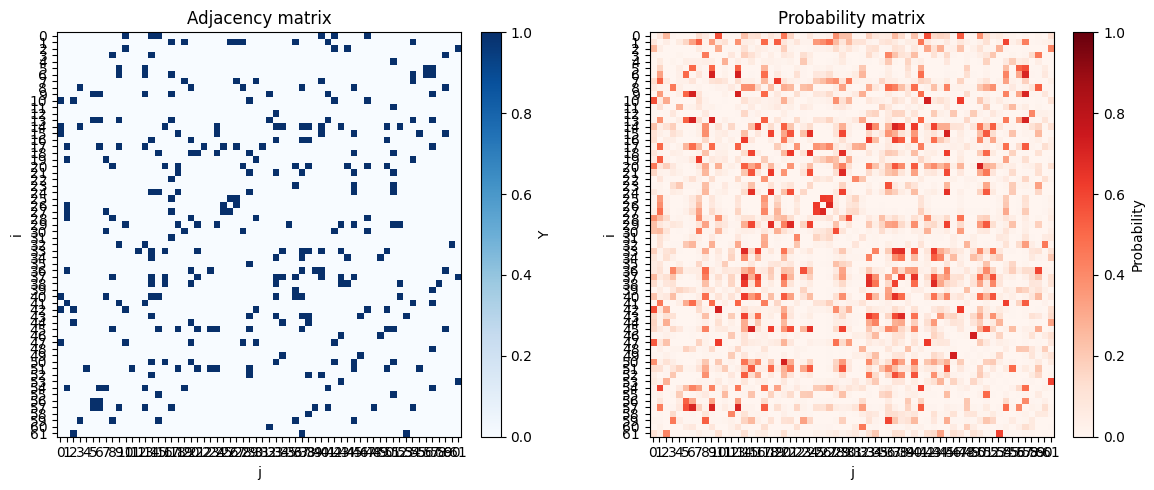

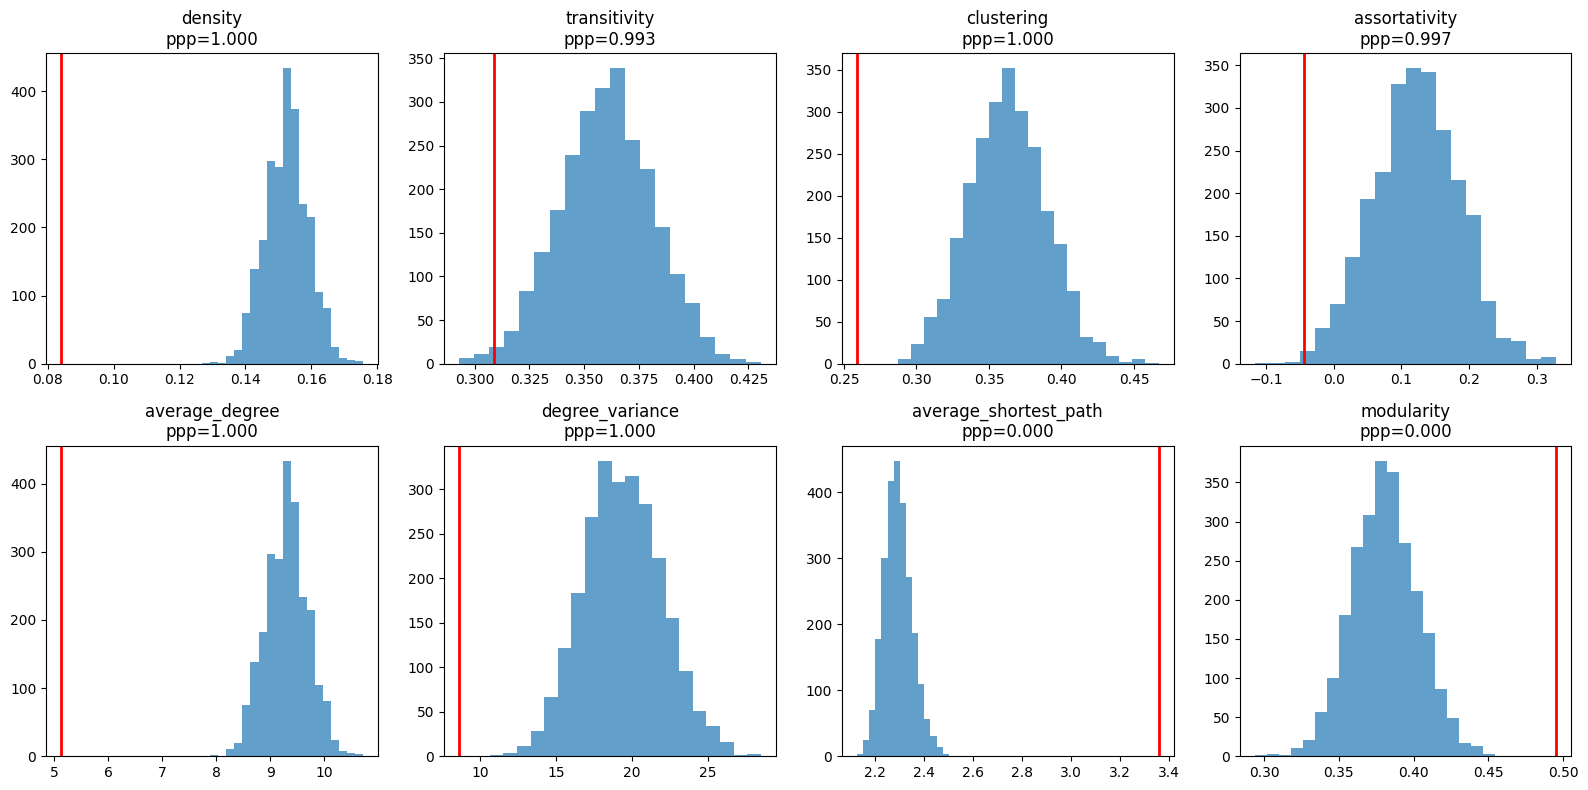

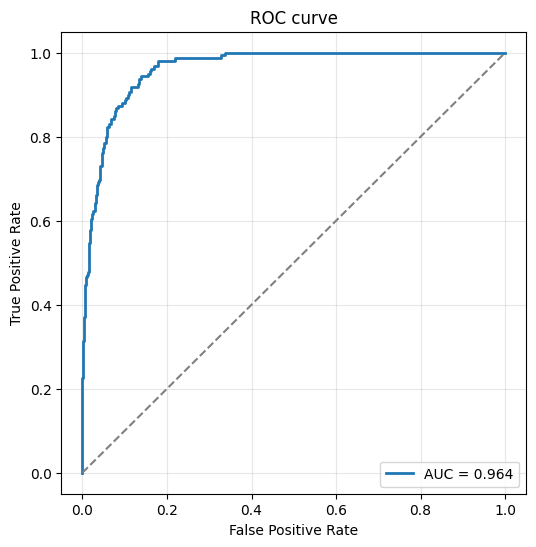

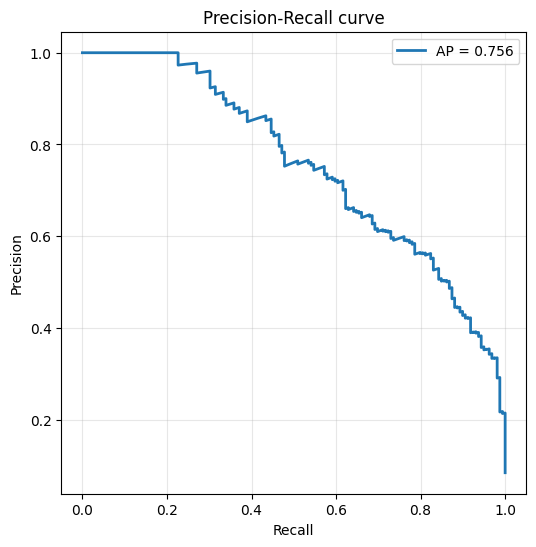

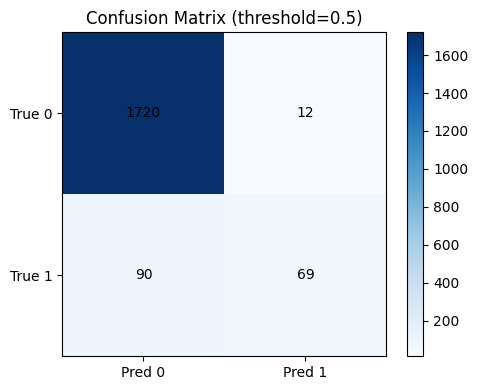

MAP:  25%|██▌       | 253/1000 [00:02<00:06, 108.29it/s, logpost=-201.9514, loglik=-201.9514, logprior=0.0000, ||grad||=0.0076, patience=49]


{'mean_auc': 0.9377723671808011, 'std_auc': 0.02335635815588566, 'min_auc': np.float64(0.9048902274708726), 'max_auc': np.float64(0.96840171463564), 'n_folds': 5}


In [18]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_S2_p.pkl")

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

#### Without weights

In [19]:
with open("Dolphins_R1_c.pkl", "rb") as f:
    results_R1_c = pickle.load(f)

Z_init = np.zeros((n,2))
Z_init[:,0:1] = np.asarray(results_R1_c['latent_params']['Z'])
for i in range(n):
    Z_init[i] = geometry.project_to_domain(Z_init[i])

Multi_start (1)


MAP:   6%|▋         | 1601/25000 [00:14<03:33, 109.68it/s, logpost=-569.1248, loglik=-568.2510, logprior=-0.8738, ||grad||=0.0139, patience=100]


[STOP] Early stopping at iter 1600 (no improvement in 101 steps)

Best log-posterior: -569.1248


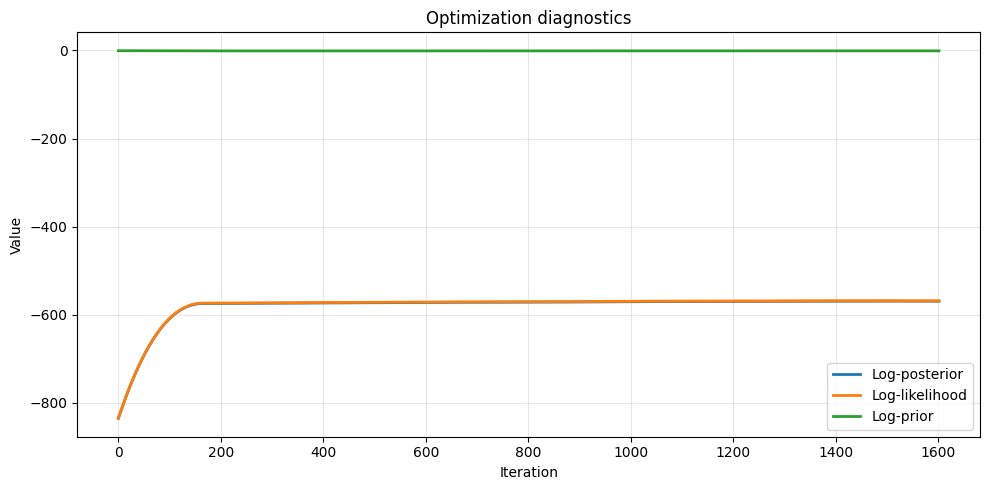

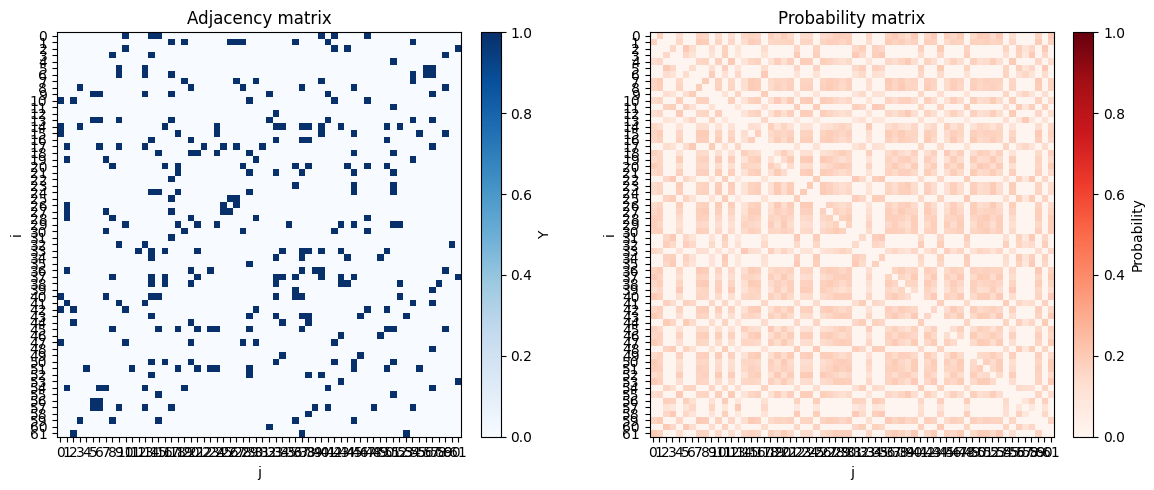

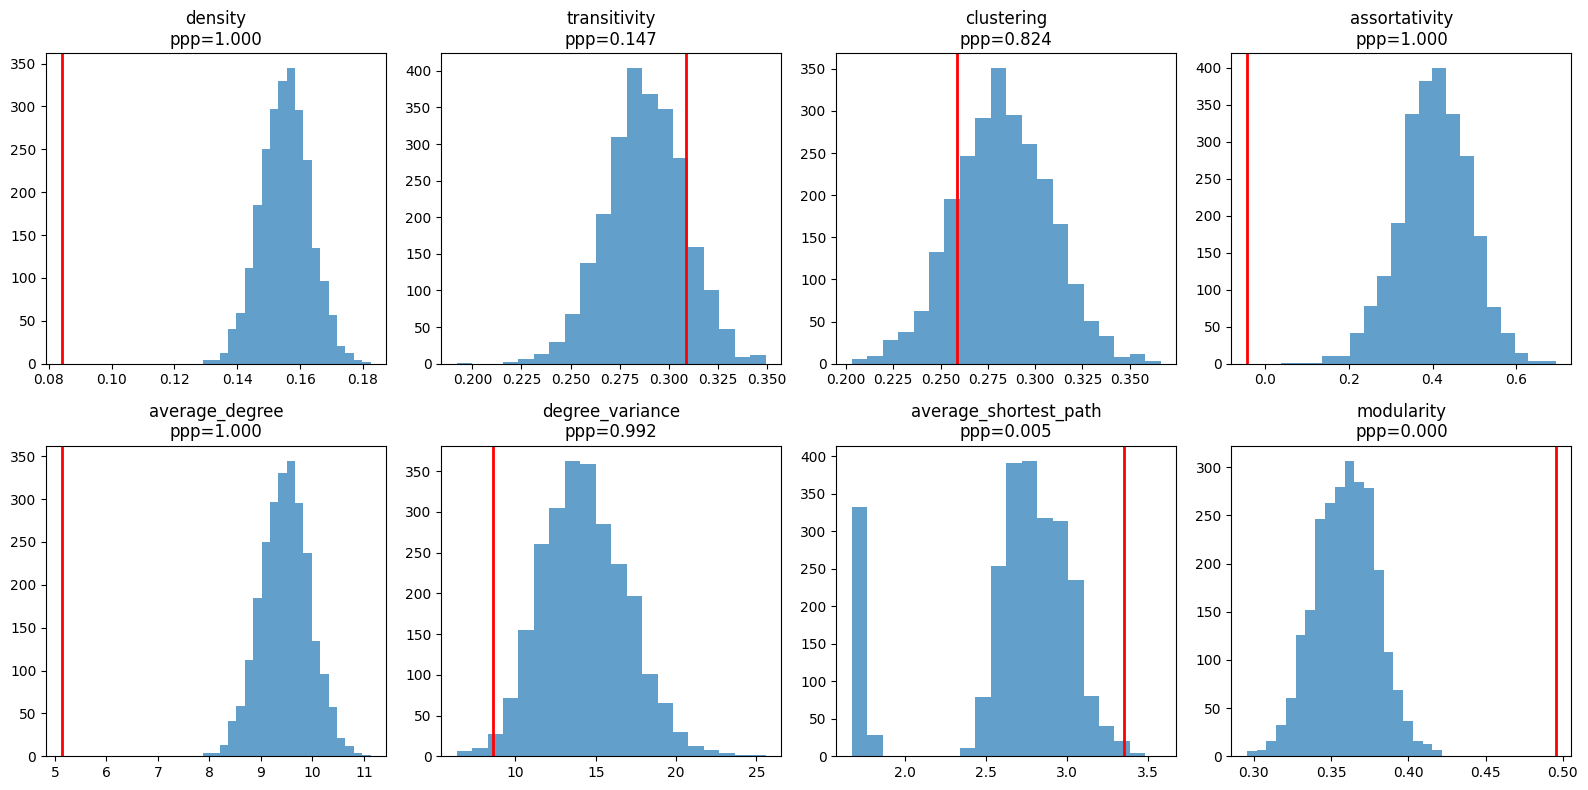

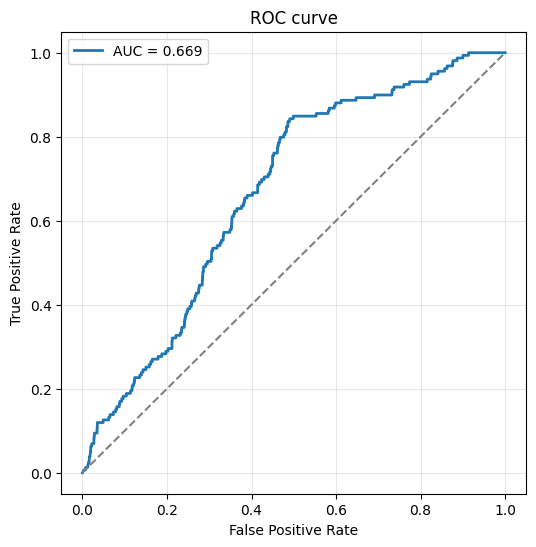

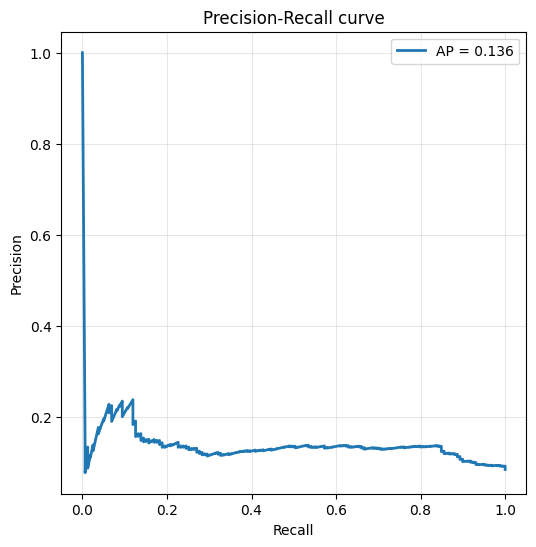

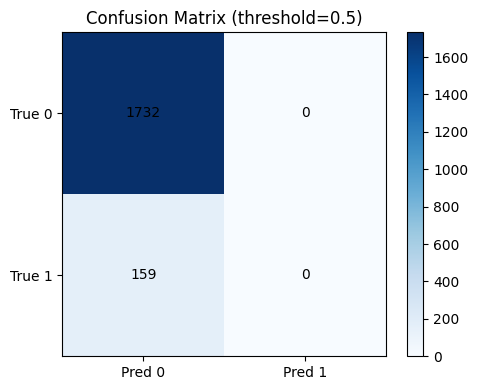

MAP:   5%|▌         | 54/1000 [00:01<00:29, 32.31it/s, logpost=-440.8298, loglik=-439.9311, logprior=-0.8988, ||grad||=0.0140, patience=49]


{'mean_auc': 0.6665472122900965, 'std_auc': 0.055401616212416765, 'min_auc': np.float64(0.5909712722298222), 'max_auc': np.float64(0.7472850678733032), 'n_folds': 5}


In [20]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_H1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:  31%|███▏      | 7826/25000 [00:31<01:09, 247.68it/s, logpost=-470.5037, loglik=-470.5037, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 7825 (no improvement in 101 steps)

Best log-posterior: -470.5037


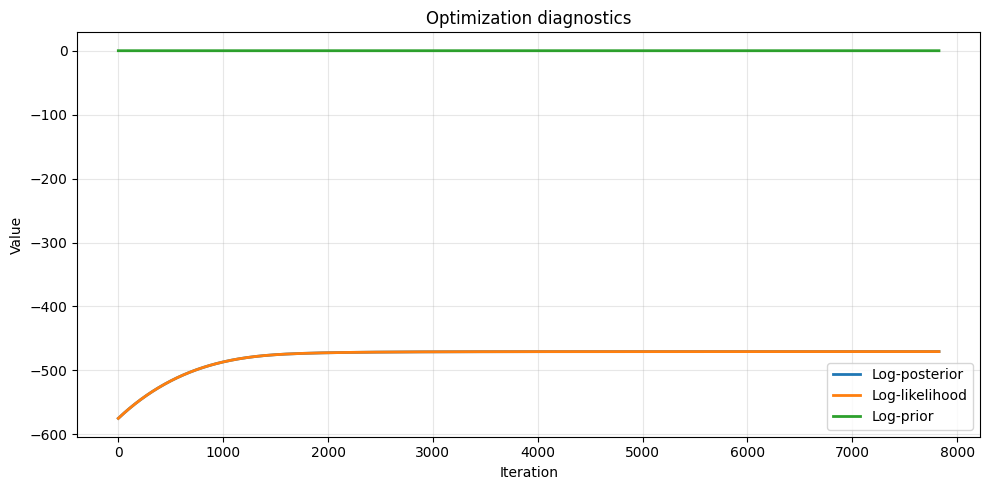

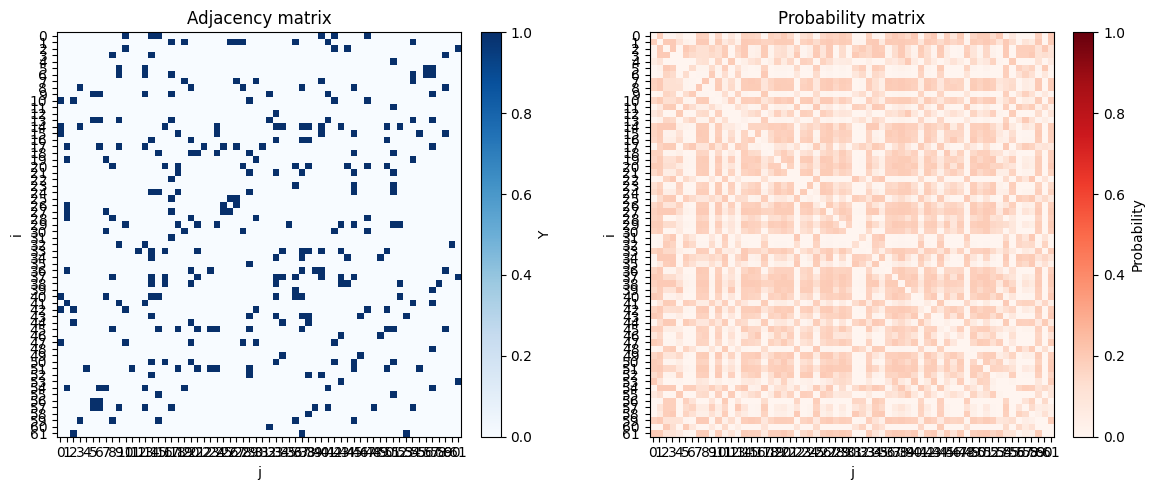

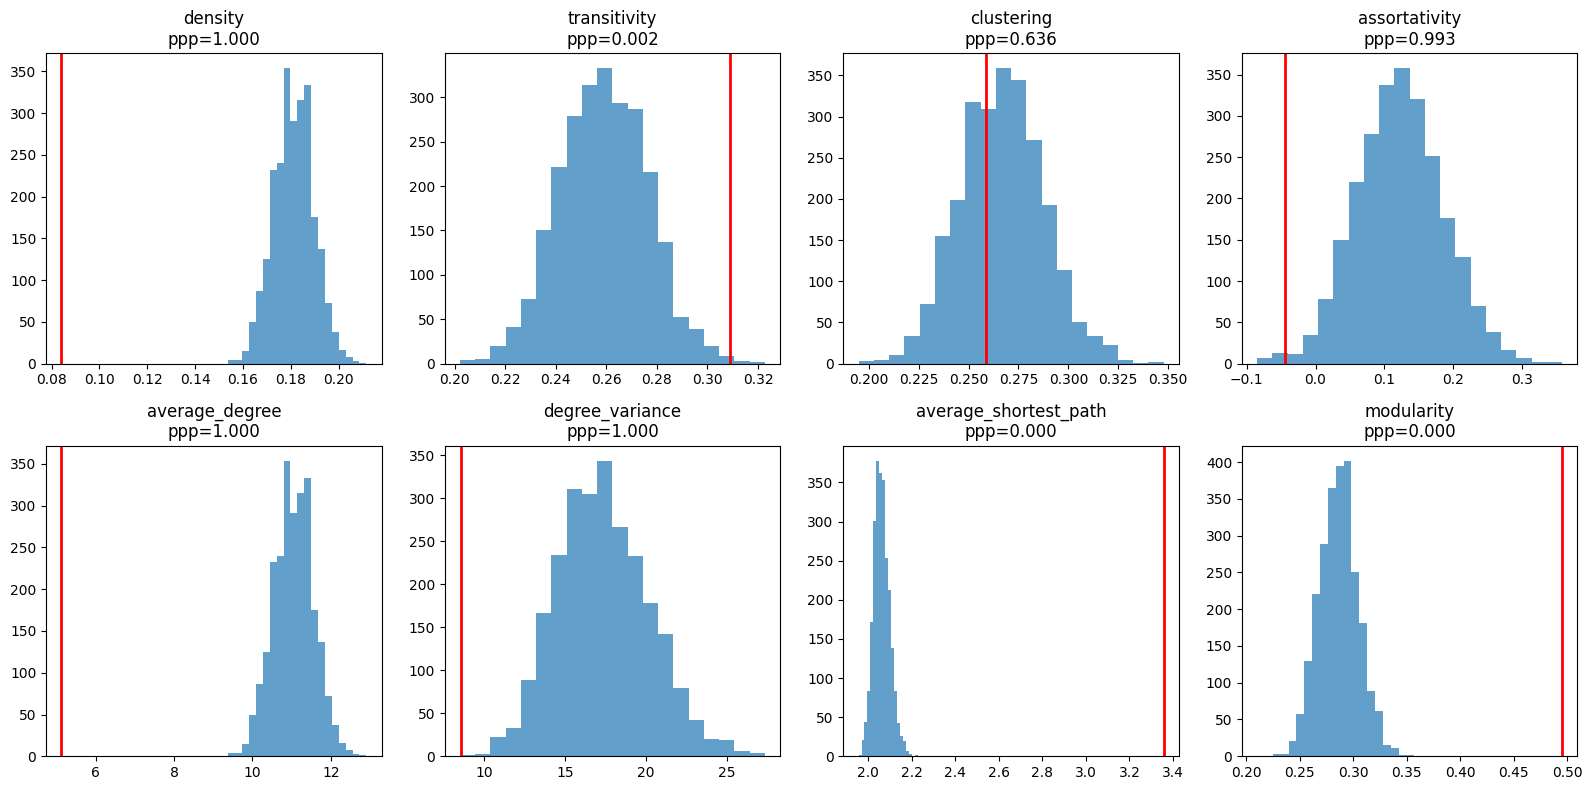

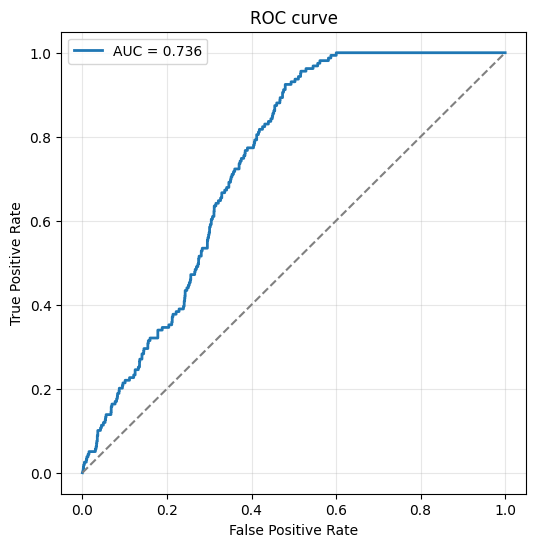

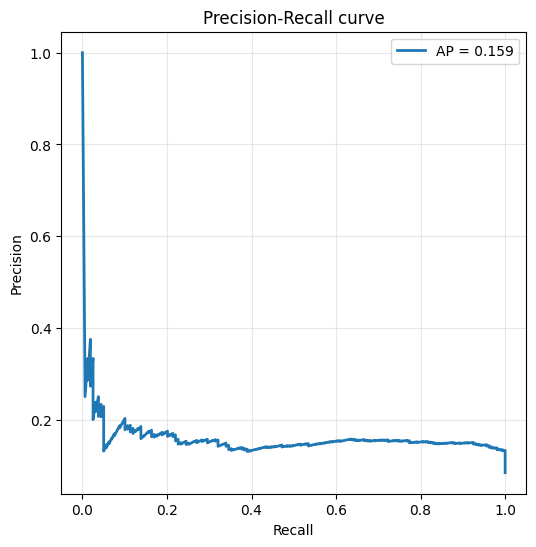

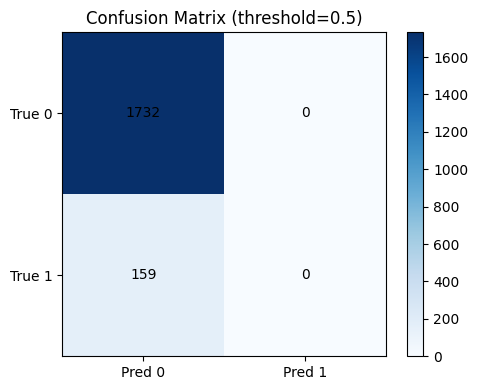

MAP: 100%|██████████| 1000/1000 [00:05<00:00, 197.37it/s, logpost=-362.4077, loglik=-362.4077, logprior=0.0000, ||grad||=0.0100, patience=0]


{'mean_auc': 0.6985250579399612, 'std_auc': 0.0444402068803989, 'min_auc': np.float64(0.6472749540722595), 'max_auc': np.float64(0.7579185520361991), 'n_folds': 5}


In [21]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_H1_p.pkl")

### Model $\mathbb{H}^2$

#### Without weights

In [22]:
with open("Dolphins_R2_p.pkl", "rb") as f:
    results_R2_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,0:2] = np.asarray(results_R2_p['latent_params']['Z'])

Multi_start (1)


MAP:   2%|▏         | 586/25000 [00:06<04:38, 87.57it/s, logpost=-322.5727, loglik=-321.9714, logprior=-0.6013, ||grad||=0.0140, patience=100] 


[STOP] Early stopping at iter 585 (no improvement in 101 steps)

Best log-posterior: -322.5727


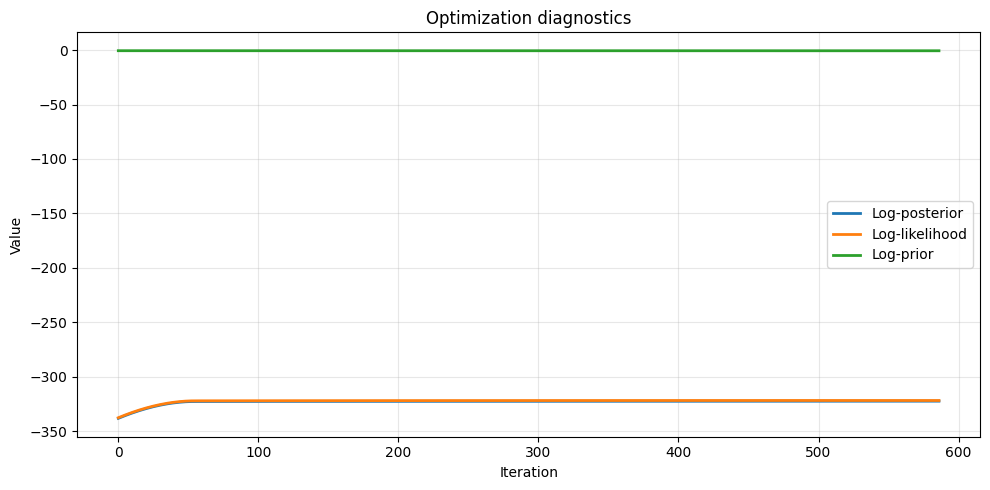

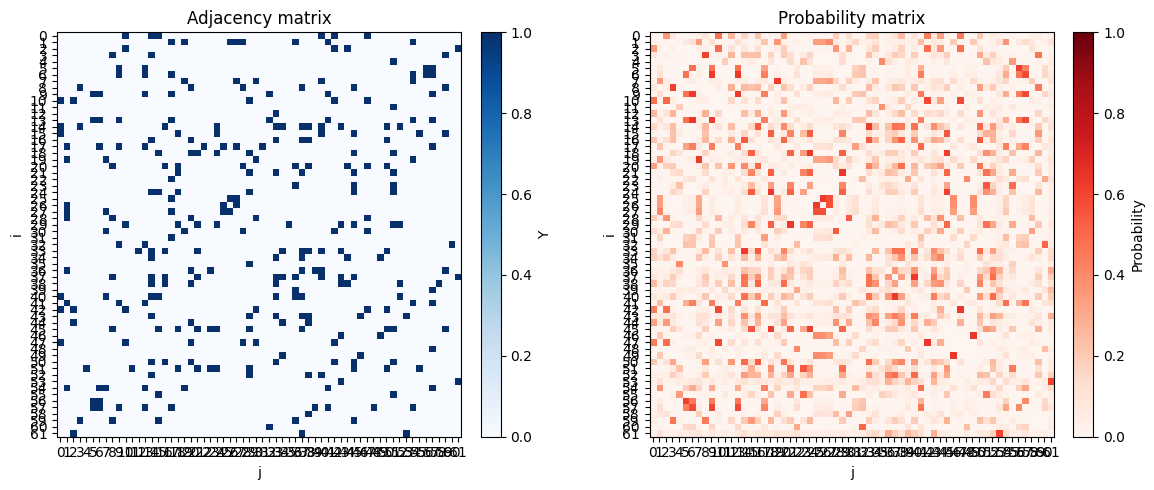

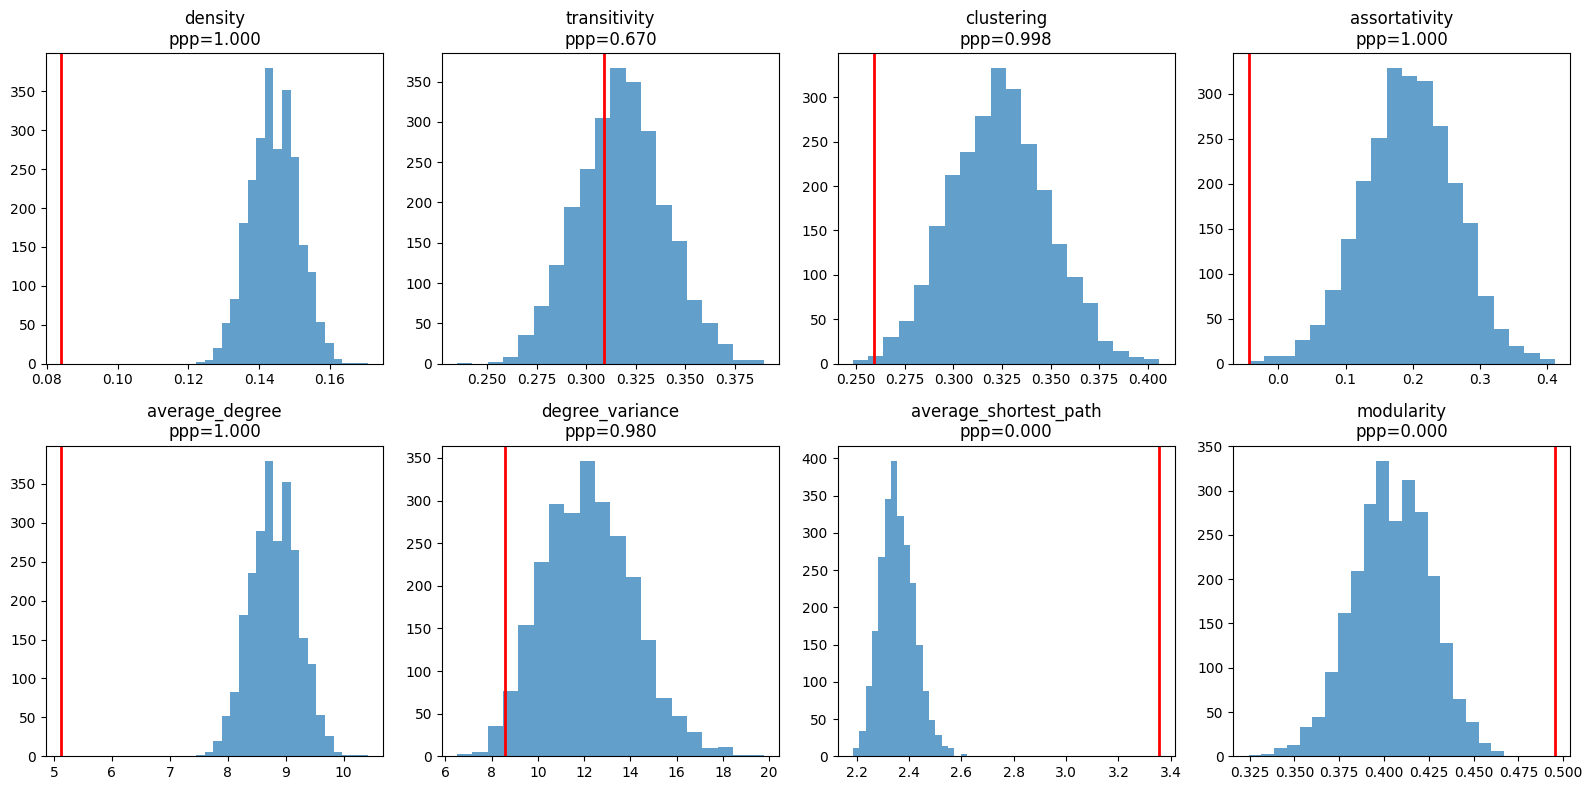

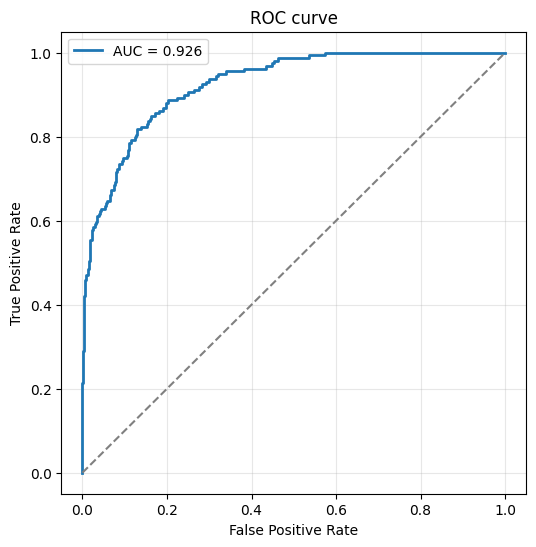

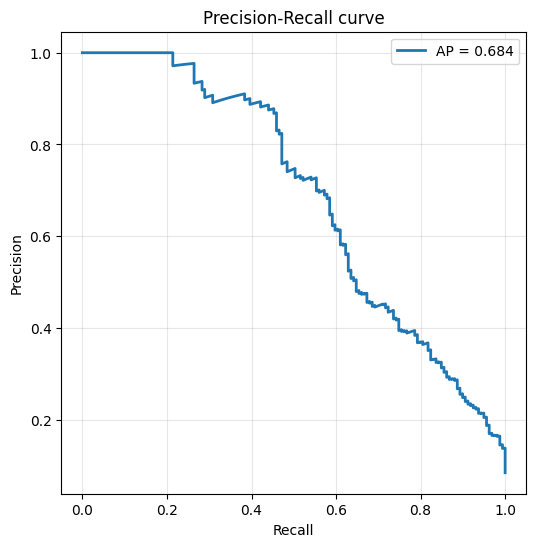

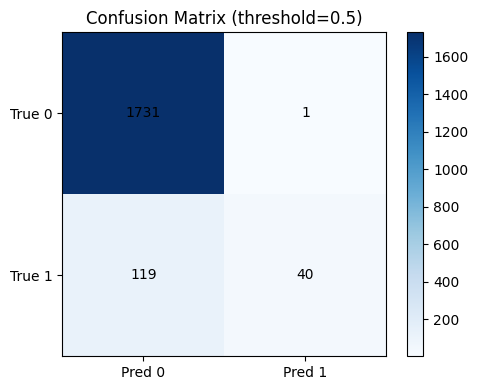

MAP:   5%|▌         | 54/1000 [00:01<00:28, 33.05it/s, logpost=-241.9804, loglik=-241.3867, logprior=-0.5937, ||grad||=0.0140, patience=49]


{'mean_auc': 0.9278470469782455, 'std_auc': 0.027659539661587417, 'min_auc': np.float64(0.8926844733296346), 'max_auc': np.float64(0.9658297611757501), 'n_folds': 5}


In [23]:
geometry = HyperbolicGeometry(d=2, D=10.0)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_H2_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:   6%|▌         | 1398/25000 [00:07<02:01, 193.72it/s, logpost=-304.8287, loglik=-304.8287, logprior=0.0000, ||grad||=0.0076, patience=100]


[STOP] Early stopping at iter 1397 (no improvement in 101 steps)

Best log-posterior: -304.8287


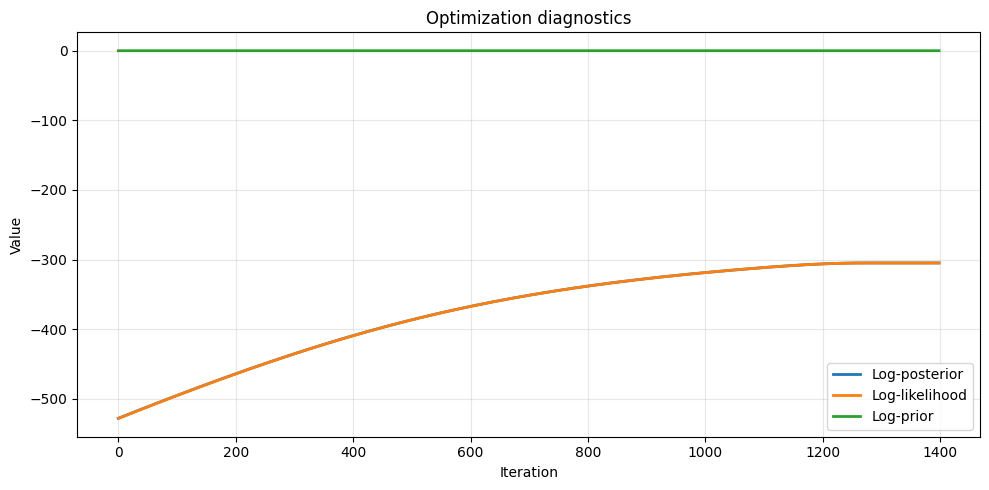

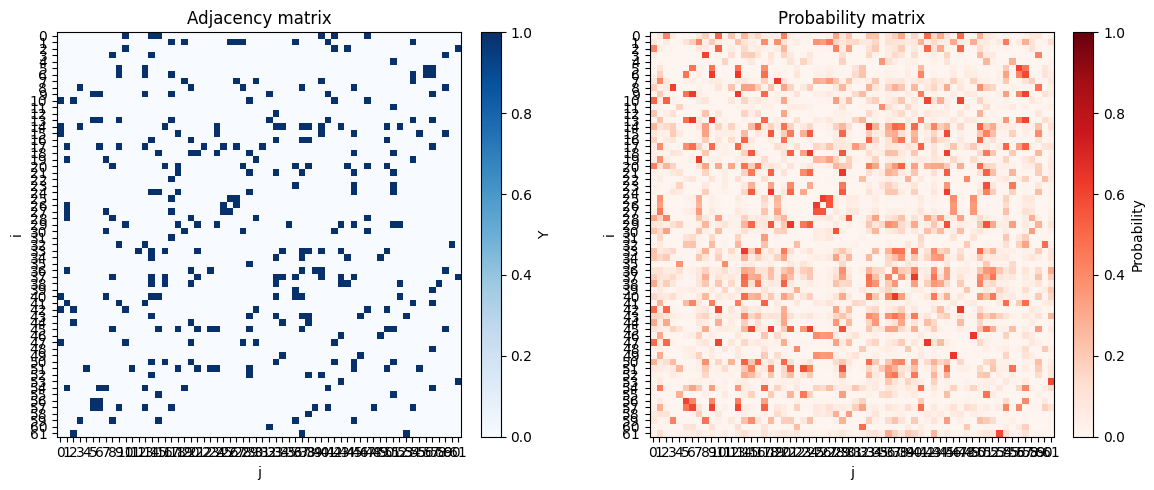

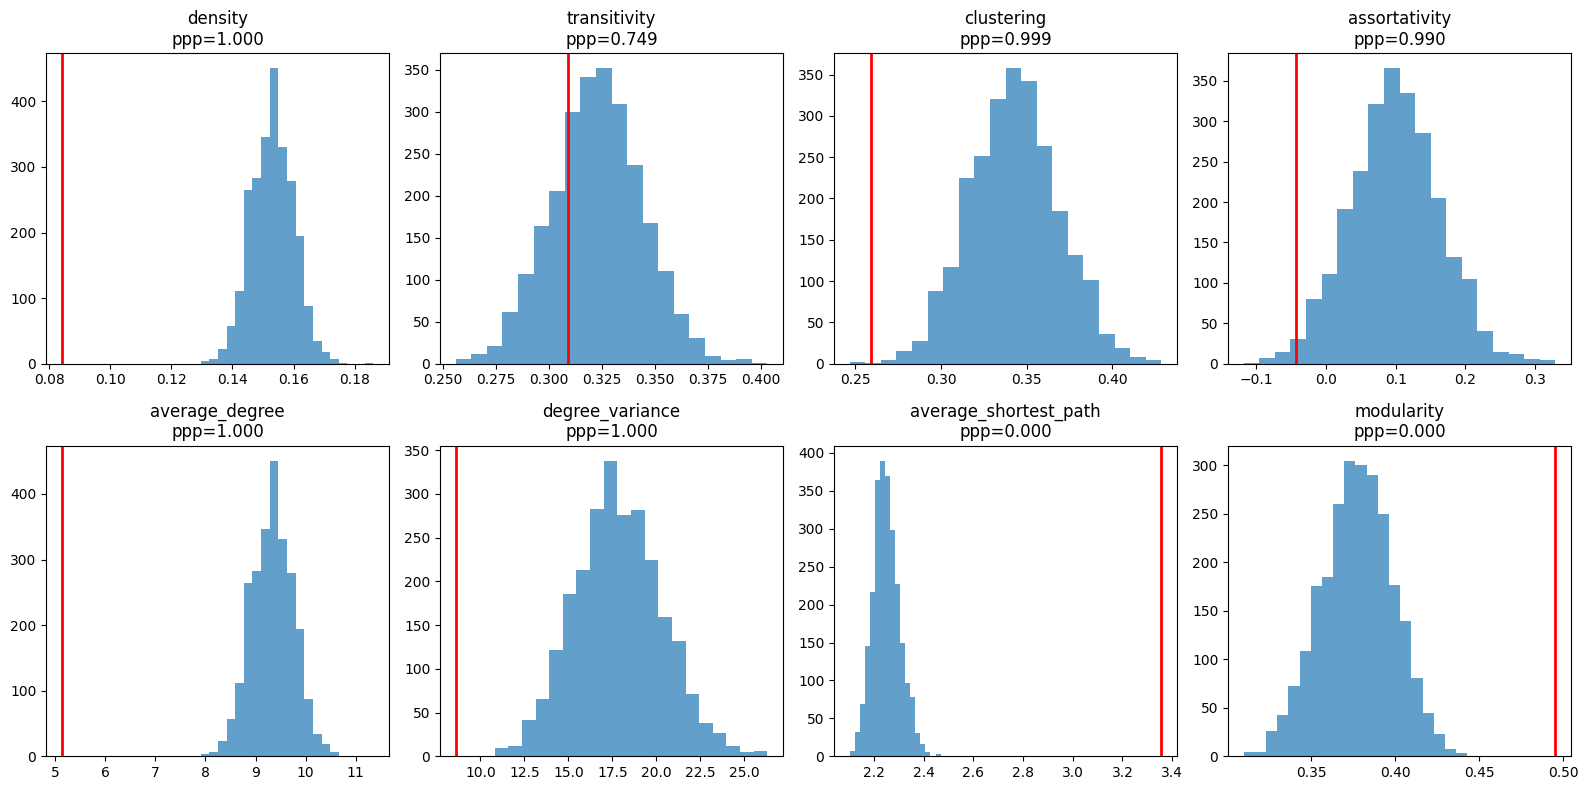

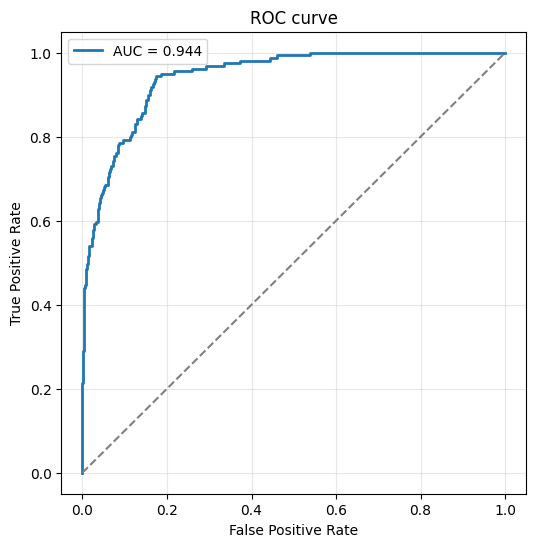

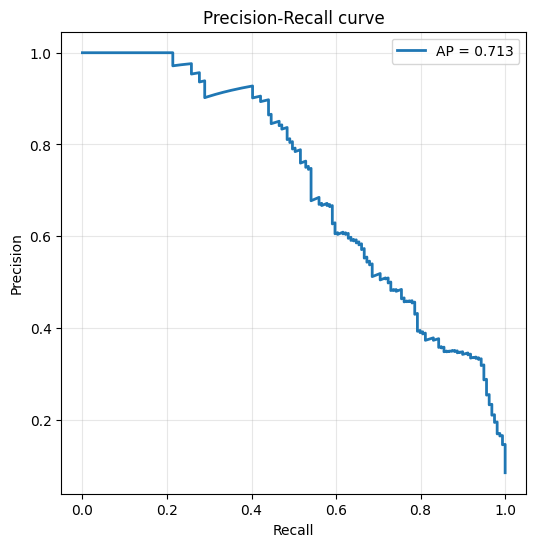

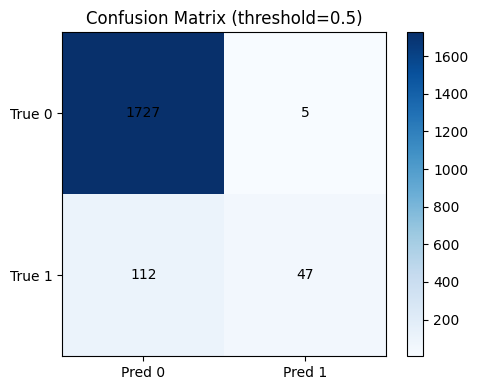

MAP:  27%|██▋       | 266/1000 [00:02<00:06, 111.88it/s, logpost=-225.9577, loglik=-225.9577, logprior=0.0000, ||grad||=0.0062, patience=49]


{'mean_auc': 0.906866544452878, 'std_auc': 0.030088369726918297, 'min_auc': np.float64(0.8643893160022192), 'max_auc': np.float64(0.945254133496632), 'n_folds': 5}


In [24]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.9*lr_MAP)
print(analysis.cross_validation_summary())

model.save("Dolphins_H2_p.pkl")

## Results

### External validation